# MedGS benchmark A — data preparation and validation

This notebook prepares the **CVPR 2024 UVI-Net 4D-Lung benchmark data** for the MedGS comparison.


## 1. Download the CVPR preprocessing

Use the original 4D-Lung preprocessing released with UVI-Net for the CVPR 2024 benchmark, not the later improved version.

Repository:
https://github.com/jungeun122333/UVI-Net

Preprocessed data:
https://drive.google.com/drive/folders/1o5w6dn4qN6EHbevO9JLrj6ej7VclaVbH

Eg. download the data with:

```bash
cd /home/jovyan/shared/mtm_medgs_stack/data
mkdir -p uvi_net
cd uvi_net

python -m pip install --user -q gdown
python -m gdown --folder "https://drive.google.com/drive/folders/1o5w6dn4qN6EHbevO9JLrj6ej7VclaVbH"
```

Use the folder labeled **CVPR version**. Do not use the later improved preprocessing.

Unzip:
```
cd "/home/jovyan/shared/mtm_medgs_stack/data/uvi_net/CVPR 2024 UVI-Net 4D-Lung dataset release"

unzip -q "4D-Lung-Preprocessed (CVPR version).zip" \
  -d /home/jovyan/shared/mtm_medgs_stack/data/uvi_net/
```

In [1]:
from pathlib import Path

import gc
import json
import math
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import os
import pandas as pd
import subprocess
import sys
import torch
import torch.nn.functional as F

from medgs4d.results import (
    load_run,
    load_run_models,
)

STACK_ROOT = Path("/home/jovyan/shared/mtm_medgs_stack")
DATA_ROOT = STACK_ROOT / "data" / "uvi_net" / "4D-Lung-Preprocessed"
OUTPUT_DIR = STACK_ROOT / "results" / "medgs_benchmark_A"

assert DATA_ROOT.is_dir(), DATA_ROOT

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATA_ROOT)
print("Output:", OUTPUT_DIR)

DEVICE = "cuda:1"
DEV_PHASES = (10, 20, 30, 40)

Dataset: /home/jovyan/shared/mtm_medgs_stack/data/uvi_net/4D-Lung-Preprocessed
Output: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A


In [2]:
def plot_phase_metric(
        metrics: pd.DataFrame,
        metric: str,
        output_path: Path,
) -> None:
    """Plot one reconstruction metric across benchmark phases."""

    data = metrics.sort_values("PhasePercent")

    figure, axis = plt.subplots(
        figsize=(6.5, 4.2),
        constrained_layout=True,
    )

    axis.plot(
        data["PhasePercent"],
        data[metric],
        marker="o",
        linewidth=1.8,
        label="MedGS",
    )

    axis.set_xticks(data["PhasePercent"])
    axis.set_xlabel("Respiratory phase (%)")
    axis.set_ylabel(metric)
    axis.grid(alpha=0.2)
    axis.legend(frameon=False)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Saved {metric} plot:", output_path)


def plot_phase_reconstructions(
        ground_truth: dict[int, np.ndarray],
        predictions: dict[int, np.ndarray],
        slice_index: int,
        output_path: Path,
) -> None:
    """Compare ground truth, MedGS reconstruction, and absolute error."""

    phases = sorted(ground_truth)

    assert phases == sorted(predictions)

    displayed = []

    for phase in phases:
        gt_slice = ground_truth[phase][:, :, slice_index].T
        pred_slice = predictions[phase][:, :, slice_index].T
        error_slice = np.abs(gt_slice - pred_slice)

        displayed.append(
            (phase, gt_slice, pred_slice, error_slice)
        )

    error_max = max(
        error.max()
        for _, _, _, error in displayed
    )

    figure, axes = plt.subplots(
        3,
        len(phases),
        figsize=(3.0 * len(phases), 8.0),
        constrained_layout=True,
        squeeze=False,
    )

    for column, (phase, gt, pred, error) in enumerate(displayed):
        axes[0, column].imshow(
            gt,
            cmap="gray",
            vmin=0.0,
            vmax=1.0,
        )

        axes[1, column].imshow(
            pred,
            cmap="gray",
            vmin=0.0,
            vmax=1.0,
        )

        error_image = axes[2, column].imshow(
            error,
            cmap="magma",
            vmin=0.0,
            vmax=error_max,
        )

        axes[0, column].set_title(f"{phase}%")

        for row in range(3):
            axes[row, column].axis("off")

    axes[0, 0].set_ylabel(
        "Ground truth",
        rotation=0,
        labelpad=45,
    )

    axes[1, 0].set_ylabel(
        "MedGS",
        rotation=0,
        labelpad=45,
    )

    axes[2, 0].set_ylabel(
        "|GT - MedGS|",
        rotation=0,
        labelpad=45,
    )

    figure.colorbar(
        error_image,
        ax=axes[2, :],
        shrink=0.8,
        label="Absolute error",
    )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved reconstruction comparison:", output_path)


print("Benchmark plotting helpers loaded.")

Benchmark plotting helpers loaded.


## 2. Reproduce the official split

UVI-Net uses `sorted(os.listdir(...))`, takes the first 68 folders for training and the remaining folders for testing. We reproduce that split exactly and save it.

In [2]:
folders = sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir())

assert len(folders) == 82, f"Expected 82 folders, found {len(folders)}"

train_folders = folders[:68]
test_folders = folders[68:]

all_patients = sorted({name.split("_")[0] for name in folders})
test_patients = sorted({name.split("_")[0] for name in test_folders})

assert len(train_folders) == 68
assert len(test_folders) == 14
assert len(all_patients) == 20
assert len(test_patients) == 2

print("All folders:", len(folders))
print("All patients:", len(all_patients))
print("Train folders:", len(train_folders))
print("Test folders:", len(test_folders))
print("Test patients:", test_patients)
print("\nTest folders:")
for name in test_folders:
    print(" ", name)

All folders: 82
All patients: 20
Train folders: 68
Test folders: 14
Test patients: ['118', '119']

Test folders:
  118_0
  118_1
  118_2
  118_3
  118_4
  118_5
  119_0
  119_1
  119_2
  119_3
  119_4
  119_5
  119_6
  119_7


In [3]:
split_metadata = {
    "dataset": "4D-Lung-Preprocessed",
    "preprocessing_release": "CVPR submission",
    "split_rule": "sorted folders; first 68 train, remaining 14 test",
    "train_folders": train_folders,
    "test_folders": test_folders,
    "test_patients": test_patients,
}

(OUTPUT_DIR / "benchmark_split.json").write_text(
    json.dumps(split_metadata, indent=2),
    encoding="utf-8",
)
(OUTPUT_DIR / "test_folders.txt").write_text(
    "\n".join(test_folders) + "\n",
    encoding="utf-8",
)
(OUTPUT_DIR / "test_patients.txt").write_text(
    "\n".join(test_patients) + "\n",
    encoding="utf-8",
)

print("Saved:")
print(" ", OUTPUT_DIR / "benchmark_split.json")
print(" ", OUTPUT_DIR / "test_folders.txt")
print(" ", OUTPUT_DIR / "test_patients.txt")

Saved:
  /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/benchmark_split.json
  /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/test_folders.txt
  /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/test_patients.txt


## 3. Validate file structure and NIfTI headers

Each case should contain ten phases (`frame0` to `frame9`). The benchmark interpolation later uses `frame0` and `frame5` as inputs and `frame1`–`frame4` as ground truth.

In [4]:
expected_shape = (128, 128, 128)

missing = []
wrong_shapes = []
case_orientations = {}

for folder in folders:
    orientations = set()

    for frame in range(10):
        path = DATA_ROOT / folder / f"ct_{folder}_frame{frame}.nii.gz"

        if not path.is_file():
            missing.append(str(path))
            continue

        img = nib.load(path)

        if img.shape != expected_shape:
            wrong_shapes.append((folder, frame, img.shape))

        orientations.add(nib.aff2axcodes(img.affine))

    case_orientations[folder] = sorted(orientations)

assert not missing, f"Missing files: {missing[:5]}"
assert not wrong_shapes, f"Unexpected shapes: {wrong_shapes[:5]}"

inconsistent_cases = {
    folder: orientations
    for folder, orientations in case_orientations.items()
    if len(orientations) != 1
}
assert not inconsistent_cases, inconsistent_cases

unique_orientations = sorted({
    orientation
    for orientations in case_orientations.values()
    for orientation in orientations
})

print("All 82 cases contain frame0-frame9.")
print("All volumes have shape:", expected_shape)
print("Orientations present across cases:", unique_orientations)

All 82 cases contain frame0-frame9.
All volumes have shape: (128, 128, 128)
Orientations present across cases: [('L', 'A', 'S')]


## 4. Check voxel values on representative test cases

We load three test cases and verify finite values and the expected `[0, 1]` intensity range for phases `0`–`5`.

In [5]:
sample_folders = [
    test_folders[0],
    test_folders[len(test_folders) // 2],
    test_folders[-1],
]

qc_rows = []

for folder in sample_folders:
    for frame in range(6):
        path = DATA_ROOT / folder / f"ct_{folder}_frame{frame}.nii.gz"
        img = nib.load(path)
        volume = img.get_fdata(dtype=np.float32)

        row = {
            "folder": folder,
            "frame": frame,
            "shape": volume.shape,
            "min": float(volume.min()),
            "max": float(volume.max()),
            "mean": float(volume.mean()),
            "finite": bool(np.isfinite(volume).all()),
            "orientation": "".join(nib.aff2axcodes(img.affine)),
        }
        qc_rows.append(row)

        assert row["finite"]
        assert volume.shape == (128, 128, 128)
        assert row["min"] >= -1e-6
        assert row["max"] <= 1.0 + 1e-6

for row in qc_rows:
    print(
        f"{row['folder']:>8} frame{row['frame']}  "
        f"shape={row['shape']}  "
        f"range=[{row['min']:.6f}, {row['max']:.6f}]  "
        f"mean={row['mean']:.6f}  "
        f"orientation={row['orientation']}"
    )

   118_0 frame0  shape=(128, 128, 128)  range=[0.000000, 1.000000]  mean=0.208731  orientation=LAS
   118_0 frame1  shape=(128, 128, 128)  range=[0.000000, 1.000000]  mean=0.209059  orientation=LAS
   118_0 frame2  shape=(128, 128, 128)  range=[0.000000, 1.000000]  mean=0.209898  orientation=LAS
   118_0 frame3  shape=(128, 128, 128)  range=[0.000000, 1.000000]  mean=0.210674  orientation=LAS
   118_0 frame4  shape=(128, 128, 128)  range=[0.000000, 1.000000]  mean=0.211393  orientation=LAS
   118_0 frame5  shape=(128, 128, 128)  range=[0.000000, 1.000000]  mean=0.211569  orientation=LAS
   119_1 frame0  shape=(128, 128, 128)  range=[0.000000, 1.000000]  mean=0.175224  orientation=LAS
   119_1 frame1  shape=(128, 128, 128)  range=[0.000000, 1.000000]  mean=0.176076  orientation=LAS
   119_1 frame2  shape=(128, 128, 128)  range=[0.000000, 1.000000]  mean=0.176169  orientation=LAS
   119_1 frame3  shape=(128, 128, 128)  range=[0.000000, 1.000000]  mean=0.176303  orientation=LAS
   119_1 f

## 5. Visual inspection

First inspect the temporal sequence `frame0`–`frame5`. Then inspect the three orthogonal central slices of `frame0`.

The anatomy should remain consistently oriented across phases, while respiratory motion should change smoothly from frame to frame.

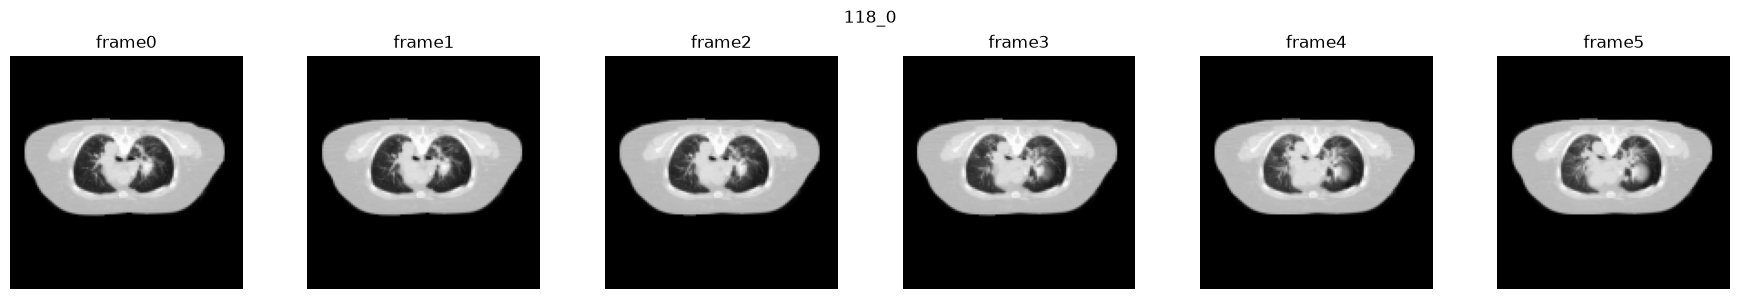

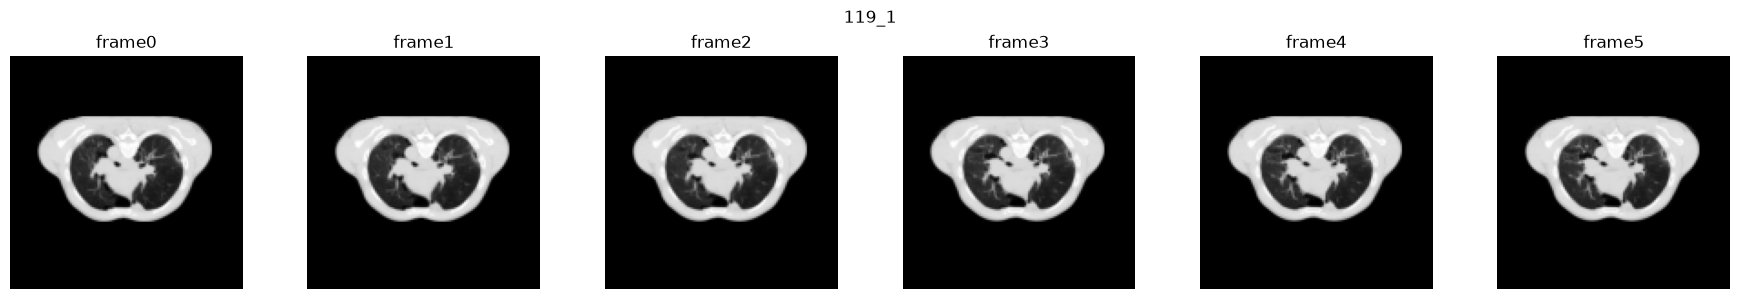

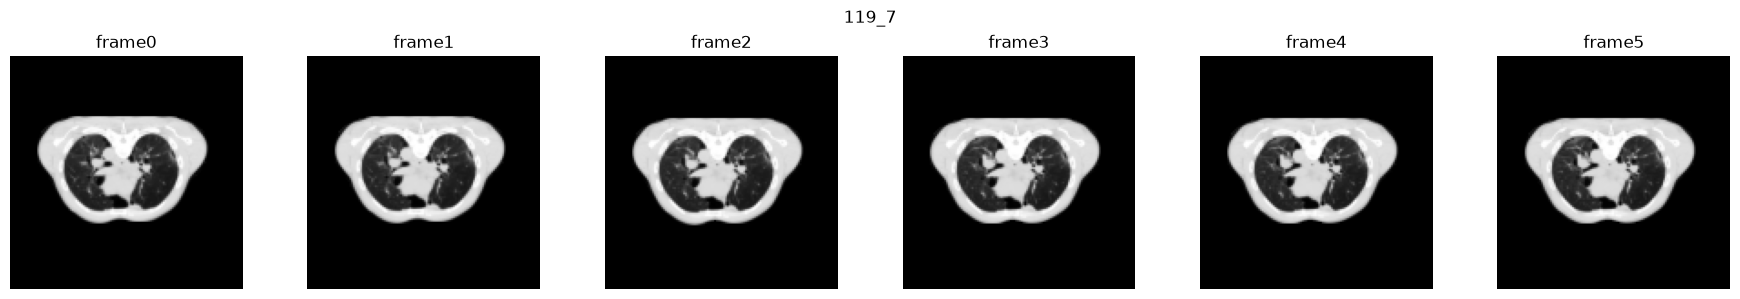

In [6]:
for folder in sample_folders:
    fig, axes = plt.subplots(1, 6, figsize=(18, 3))

    for frame, ax in enumerate(axes):
        path = DATA_ROOT / folder / f"ct_{folder}_frame{frame}.nii.gz"
        volume = nib.load(path).get_fdata(dtype=np.float32)

        z = volume.shape[2] // 2
        ax.imshow(volume[:, :, z].T, cmap="gray", origin="lower", vmin=0, vmax=1)
        ax.set_title(f"frame{frame}")
        ax.axis("off")

    fig.suptitle(folder)
    plt.tight_layout()
    plt.show()

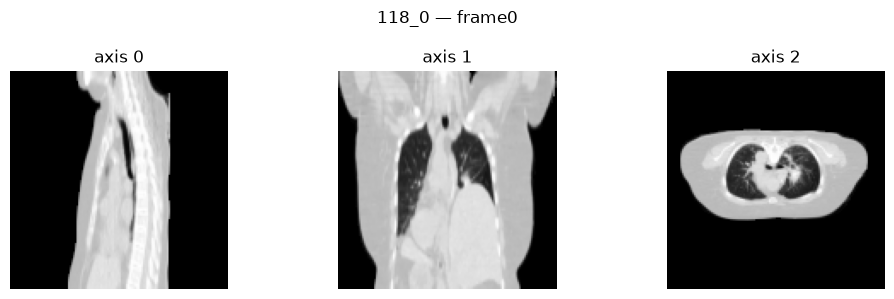

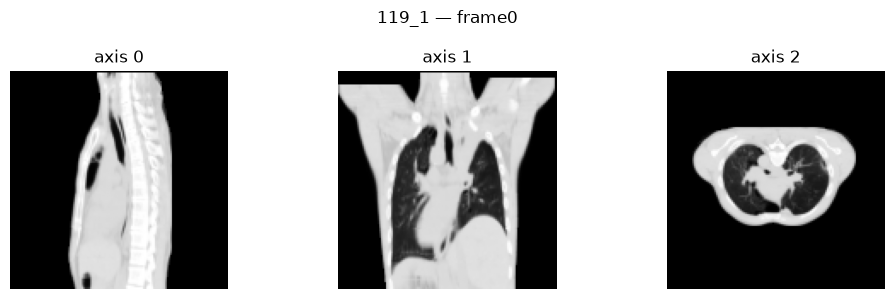

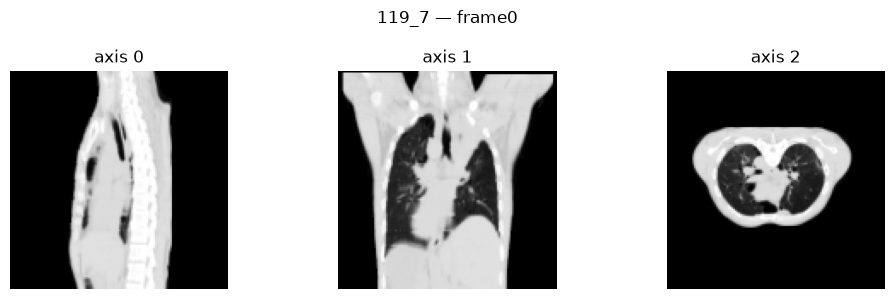

In [7]:
for folder in sample_folders:
    path = DATA_ROOT / folder / f"ct_{folder}_frame0.nii.gz"
    volume = nib.load(path).get_fdata(dtype=np.float32)

    cx, cy, cz = (n // 2 for n in volume.shape)

    views = [
        ("axis 0", volume[cx, :, :]),
        ("axis 1", volume[:, cy, :]),
        ("axis 2", volume[:, :, cz]),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    for ax, (title, image) in zip(axes, views):
        ax.imshow(image.T, cmap="gray", origin="lower", vmin=0, vmax=1)
        ax.set_title(title)
        ax.axis("off")

    fig.suptitle(f"{folder} — frame0")
    plt.tight_layout()
    plt.show()

In [8]:
def load_frame(case: str, frame: int) -> np.ndarray:
    path = DATA_ROOT / case / f"ct_{case}_frame{frame}.nii.gz"
    return nib.load(path).get_fdata(dtype=np.float32)


for case in test_folders:
    for frame in range(6):
        volume = load_frame(case, frame)

        assert volume.shape == (128, 128, 128), (case, frame, volume.shape)
        assert np.isfinite(volume).all(), (case, frame, "non-finite values")
        assert volume.min() >= -1e-6, (case, frame, volume.min())
        assert volume.max() <= 1.0 + 1e-6, (case, frame, volume.max())

print("Validated all 14 test cases for frames 0-5.")
print("Checks: shape=128^3, finite values, intensity range within [0, 1].")

Validated all 14 test cases for frames 0-5.
Checks: shape=128^3, finite values, intensity range within [0, 1].


## 6. Prepare the benchmark case for MedGS4D

The benchmark case is converted to the existing MedGS4D study format. Only the observed 0% and 50% phases are included.

The NIfTI volumes are stored as axial slice stacks expected by the MedGS pipeline. Respiratory phases follow the existing MedGS4D convention, where phase percentages correspond to normalized times `0.0` and `0.5`.

In [3]:

MEDGS4D_ROOT = STACK_ROOT / "repo" / "medgs4d"
MEDGS_REPO = STACK_ROOT / "repo" / "MedGS"

sys.path.insert(0, str(MEDGS4D_ROOT))

from medgs4d.data import StudyManifest, save_study_manifest

In [9]:

CASE = "118_0"
STUDY_DIR = OUTPUT_DIR / "prepared" / CASE
RAW_DIR = STUDY_DIR / "volumes" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

phase_to_frame = {
    0.0: 0,
    50.0: 5,
}

raw_paths = {}

for phase, frame in phase_to_frame.items():
    volume = load_frame(CASE, frame)

    # MedGS uses the first dimension as the axial slice index.
    volume = np.transpose(volume, (2, 1, 0)).astype(np.float32)

    path = RAW_DIR / f"phase_{int(phase):02d}.npy"
    np.save(path, volume)
    raw_paths[phase] = str(path.resolve())

phase_slice_manifest = pd.DataFrame(
    [
        {
            "PhasePercent": phase,
            "SliceIndex": slice_index,
            "SliceCoordinate": float(slice_index),
        }
        for phase in phase_to_frame
        for slice_index in range(128)
    ]
)

phase_slice_path = STUDY_DIR / "phase_slice_manifest.csv"
phase_slice_manifest.to_csv(phase_slice_path, index=False)

phase_summary_path = STUDY_DIR / "phase_summary.csv"
pd.DataFrame(
    {
        "PhasePercent": list(phase_to_frame),
        "SliceCount": [128, 128],
    }
).to_csv(phase_summary_path, index=False)

study = StudyManifest(
    study_name=f"benchmark_{CASE}",
    patient_id=CASE.split("_")[0],
    study_instance_uid=f"benchmark_{CASE}",
    phases=(0.0, 50.0),
    slice_count=128,
    volume_shape=(128, 128, 128),
    hu_window=(0.0, 1.0),
    denoise_sigma=(0.0, 0.0, 0.0),
    raw_volume_paths=raw_paths,
    denoised_volume_paths=raw_paths.copy(),
    phase_slice_manifest_path=str(phase_slice_path.resolve()),
    phase_summary_path=str(phase_summary_path.resolve()),
)

save_study_manifest(study, STUDY_DIR)

print("Prepared case:", CASE)
print("Training phases:", study.phases)
print("Volume shape:", study.volume_shape)

Prepared case: 118_0
Training phases: (0.0, 50.0)
Volume shape: (128, 128, 128)


### Canonical MedGS training

The 0% phase is used to train the canonical MedGS representation. This produces the Gaussian representation that will subsequently be deformed using the observed 50% phase.

In [10]:


PYTHON = STACK_ROOT / "envs" / "medgs-worf" / "bin" / "python"

CANONICAL_ROOT = OUTPUT_DIR / "canonical"
CANONICAL_RUN_NAME = "phase00_iter15000"
CANONICAL_RUN = CANONICAL_ROOT / f"benchmark_{CASE}" / CANONICAL_RUN_NAME

env = os.environ.copy()
env["CUDA_VISIBLE_DEVICES"] = "1"

command = [
    str(PYTHON),
    str(MEDGS4D_ROOT / "scripts" / "train_canonical.py"),
    "--data-dir", str(STUDY_DIR),
    "--medgs-repo", str(MEDGS_REPO),
    "--output-root", str(CANONICAL_ROOT),
    "--run-name", CANONICAL_RUN_NAME,
    "--canonical-phase", "0",
    "--representation", "raw",
    "--iterations", "15000",
    "--poly-degree", "2",
    "--batch-size", "3",
    "--camera", "mirror",
    "--log-every", "100",
    "--force",
]

subprocess.run(command, check=True, env=env)

CANONICAL_CHECKPOINT = CANONICAL_RUN / "model" / "chkpnt15000.pth"
assert CANONICAL_CHECKPOINT.is_file()

print("Canonical training completed.")
print("Checkpoint:", CANONICAL_CHECKPOINT)

Running: /home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_118_0/phase00_iter15000/tools/train_with_history.py -s /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_118_0/phase00_iter15000/dataset -m /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_118_0/phase00_iter15000/model --pipeline img --iterations 15000 --save_iterations 15000 --test_iterations 15000 --checkpoint_iterations 15000 --poly_degree 2 --batch_size 3 --camera mirror


Training progress:   0%|          | 0/15000 [00:00<?, ?it/s]

torch cuda:  True
Optimizing /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_118_0/phase00_iter15000/model
Training with photometric loss [28/09 20:36:25]
Output folder: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_118_0/phase00_iter15000/model [28/09 20:36:25]
Tensorboard not available: not logging progress [28/09 20:36:25]
frames 128 [28/09 20:36:25]
Distance: 1.0 [28/09 20:36:25]
Creating Training Transforms [28/09 20:36:25]
Creating Test Transforms [28/09 20:36:26]
AAAAA radius 1.1 [28/09 20:36:26]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [28/09 20:36:26]
Generating random point cloud (100000)... [28/09 20:36:26]
Loading Training Cameras [28/09 20:36:26]
Loading Test Cameras [28/09 20:36:27]
Number of points at initialisation :  100000 [28/09 20:36:27]
NOT USING DFF [28/09 20:36:27]
tensor([0.0078, 0.0078, 0.0078, 0.0078, 0.0078, 0.0078, 0.0078, 0.0078, 0.0078,
        0.0078, 0.0078, 0.0078, 0.0078, 0.00

Training progress: 100%|██████████| 15000/15000 [07:03<00:00, 35.40it/s, Loss=0.0069341, psnr=41.64, point=225451]


prev_next_overlap 2 [28/09 20:36:28]

[ITER 600] Densifying Gaussians [28/09 20:36:38]

[ITER 700] Densifying Gaussians [28/09 20:36:40]

[ITER 800] Densifying Gaussians [28/09 20:36:41]

[ITER 900] Densifying Gaussians [28/09 20:36:42]

[ITER 1000] Densifying Gaussians [28/09 20:36:44]

[ITER 1100] Densifying Gaussians [28/09 20:36:45]

[ITER 1200] Densifying Gaussians [28/09 20:36:47]

[ITER 1300] Densifying Gaussians [28/09 20:36:49]

[ITER 1400] Densifying Gaussians [28/09 20:36:51]

[ITER 1500] Densifying Gaussians [28/09 20:36:53]

[ITER 1600] Densifying Gaussians [28/09 20:36:54]

[ITER 1700] Densifying Gaussians [28/09 20:36:56]

[ITER 1800] Densifying Gaussians [28/09 20:36:58]

[ITER 1900] Densifying Gaussians [28/09 20:37:00]

[ITER 2000] Densifying Gaussians [28/09 20:37:02]

[ITER 2100] Densifying Gaussians [28/09 20:37:04]

[ITER 2200] Densifying Gaussians [28/09 20:37:06]

[ITER 2300] Densifying Gaussians [28/09 20:37:08]

[ITER 2400] Densifying Gaussians [28/09 20:37:09

### Dynamic deformation training

The canonical MedGS representation is frozen and a phase-conditioned deformation network is trained using the observed 50% phase.

The prepared study contains only the canonical 0% phase and the observed 50% phase. Therefore, the `full` split assigns 0% to the canonical representation and 50% to dynamic training. Intermediate phases remain unavailable to the optimizer.

In [11]:
DYNAMIC_ROOT = OUTPUT_DIR / "dynamic"
DYNAMIC_RUN_NAME = "phase00_to50_iter7000"
DYNAMIC_RUN = DYNAMIC_ROOT / f"benchmark_{CASE}" / DYNAMIC_RUN_NAME

command = [
    str(PYTHON),
    str(MEDGS4D_ROOT / "scripts" / "train_medgs4d.py"),
    "--data-dir", str(STUDY_DIR),
    "--canonical-model", str(CANONICAL_RUN),
    "--canonical-checkpoint", str(CANONICAL_CHECKPOINT),
    "--medgs-repo", str(MEDGS_REPO),
    "--output-root", str(DYNAMIC_ROOT),
    "--run-name", DYNAMIC_RUN_NAME,
    "--canonical-phase", "0",
    "--target-representation", "raw",
    "--split-mode", "full",
    "--iterations", "7000",
    "--learning-rate", "5e-4",
    "--spatial-frequencies", "4",
    "--phase-frequencies", "2",
    "--hidden-dim", "256",
    "--hidden-layers", "4",
    "--chunk-size", "131072",
    "--checkpoint-every", "500",
    "--log-every", "25",
    "--validate-every", "0",
    "--validation-samples", "0",
    "--phase-jitter-std", "0",
    "--seed", "42",
    "--device", "cuda",
]

subprocess.run(command, check=True)

DYNAMIC_CHECKPOINT = (
        DYNAMIC_RUN
        / "checkpoints"
        / "deformation_iter_007000.pth"
)

assert DYNAMIC_CHECKPOINT.is_file()

print("Dynamic training completed.")
print("Checkpoint:", DYNAMIC_CHECKPOINT)

/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
Iteration 000025/007000 L1=0.112356 SSIM=0.795555 PSNR=13.186


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 000050/007000 L1=0.113525 SSIM=0.798740 PSNR=13.143


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


...

Iteration 006950/007000 L1=0.108212 SSIM=0.843253 PSNR=13.501


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 006975/007000 L1=0.106950 SSIM=0.842408 PSNR=13.598


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 007000/007000 L1=0.109256 SSIM=0.841904 PSNR=13.457
MedGS4D run: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/dynamic/benchmark_118_0/phase00_to50_iter7000
Dynamic training completed.
Checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/dynamic/benchmark_118_0/phase00_to50_iter7000/checkpoints/deformation_iter_007000.pth


## 7. Temporal reconstruction

The trained MedGS4D model is used to reconstruct the hidden respiratory phases at 10%, 20%, 30%, and 40%.

The intermediate ground-truth volumes are not used during rendering. They are loaded only afterwards for benchmark evaluation.

In [13]:

run = load_run(run_dir=DYNAMIC_RUN)

canonical, field = load_run_models(
    run,
    checkpoint=DYNAMIC_CHECKPOINT,
    device="cuda",
)

print("Dynamic run:", run.run_dir)
print("Dynamic checkpoint:", DYNAMIC_CHECKPOINT)
print("Canonical checkpoint:", canonical.checkpoint_path)

Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
Dynamic run: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/dynamic/benchmark_118_0/phase00_to50_iter7000
Dynamic checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/dynamic/benchmark_118_0/phase00_to50_iter7000/checkpoints/deformation_iter_007000.pth
Canonical checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_118_0/phase00_iter15000/model/chkpnt15000.pth


In [4]:
def render_phase_volume(
        phase: float,
) -> np.ndarray:
    """Render one respiratory phase as an (X, Y, Z) volume."""

    slices = []

    with torch.no_grad():
        gaussians, _ = field.build_phase_state(
            phase / 100.0,
            use_checkpointing=False,
        )

        for slice_index in range(run.study.slice_count):
            camera = get_camera_for_slice(
                canonical,
                slice_index,
            )

            image = canonical.runtime.render(
                camera,
                gaussians,
                canonical.pipeline,
                canonical.background,
            )["render"]

            gray = (
                image
                .clamp(0, 1)
                .mean(dim=0)
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            slices.append(gray)

    volume_zyx = np.stack(slices, axis=0)

    return np.transpose(
        volume_zyx,
        (2, 1, 0),
    )


print("Full-volume renderer ready.")

Full-volume renderer ready.


Prediction shape: (128, 128, 128)
Ground-truth shape: (128, 128, 128)
Mean absolute error: 0.10969876


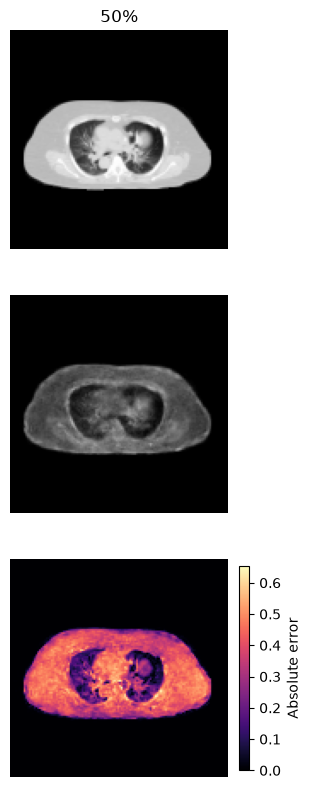

Saved reconstruction comparison: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/figures/118_0/observed_phase50_slice64.png


In [15]:
prediction_50 = render_phase_volume(50.0)
ground_truth_50 = load_frame(CASE, 5)

print("Prediction shape:", prediction_50.shape)
print("Ground-truth shape:", ground_truth_50.shape)
print(
    "Mean absolute error:",
    np.mean(np.abs(prediction_50 - ground_truth_50)),
)

plot_phase_reconstructions(
    ground_truth={50: ground_truth_50},
    predictions={50: prediction_50},
    slice_index=64,
    output_path=(
            OUTPUT_DIR
            / "figures"
            / CASE
            / "observed_phase50_slice64.png"
    ),
)

In [17]:
run = load_run(run_dir=DYNAMIC_RUN)

phase50_metrics = (
    run.per_phase_metrics
    .loc[run.per_phase_metrics["PhasePercent"] == 50.0]
    [
        [
            "PhasePercent",
            "SliceCount",
            "BaselineL1",
            "DynamicL1",
            "L1Reduction",
            "BaselinePSNR",
            "DynamicPSNR",
            "PSNRGain",
            "BaselineSSIM",
            "DynamicSSIM",
            "SSIMGain",
        ]
    ]
)

display(phase50_metrics)

print(
    "Training PSNR, last 500 iterations:",
    run.training_history.tail(500)["PSNR"].mean(),
)

,PhasePercent,SliceCount,BaselineL1,DynamicL1,L1Reduction,BaselinePSNR,DynamicPSNR,PSNRGain,BaselineSSIM,DynamicSSIM,SSIMGain
1,50.0,128,0.114022,0.109699,0.004322,13.11681,13.443771,0.326961,0.779924,0.842573,0.062648


Training PSNR, last 500 iterations: 13.43287526512146


In [16]:
PREDICTION_DIR = OUTPUT_DIR / "predictions" / CASE
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

predictions = {}

for phase in (10, 20, 30, 40):
    prediction = render_phase_volume(float(phase))

    predictions[phase] = prediction

    output_path = (
            PREDICTION_DIR
            / f"phase_{phase:02d}.npy"
    )

    np.save(output_path, prediction)

    print(
        f"Rendered phase {phase}%:",
        prediction.shape,
        "->",
        output_path,
    )

Rendered phase 10%: (128, 128, 128) -> /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/predictions/118_0/phase_10.npy
Rendered phase 20%: (128, 128, 128) -> /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/predictions/118_0/phase_20.npy
Rendered phase 30%: (128, 128, 128) -> /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/predictions/118_0/phase_30.npy
Rendered phase 40%: (128, 128, 128) -> /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/predictions/118_0/phase_40.npy


### Hidden-phase reconstruction

The saved predictions for the 10%, 20%, 30%, and 40% respiratory phases are now compared with the corresponding held-out ground-truth volumes.

The ground-truth intermediate phases are loaded only after inference and were not available during canonical or dynamic training.

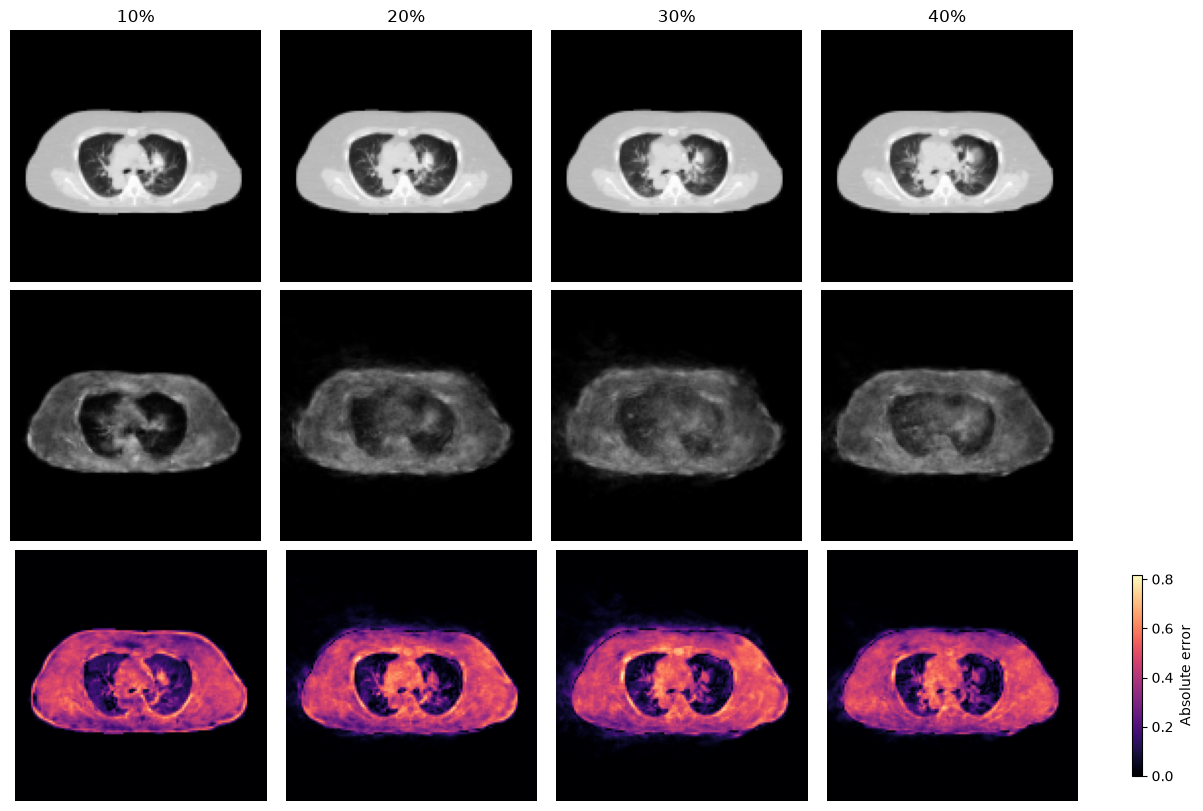

Saved reconstruction comparison: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/figures/118_0/hidden_phases_slice64.png
Compared hidden phases: [10, 20, 30, 40]
Slice: 64


In [18]:
ground_truth = {
    10: load_frame(CASE, 1),
    20: load_frame(CASE, 2),
    30: load_frame(CASE, 3),
    40: load_frame(CASE, 4),
}

plot_phase_reconstructions(
    ground_truth=ground_truth,
    predictions=predictions,
    slice_index=64,
    output_path=(
            OUTPUT_DIR
            / "figures"
            / CASE
            / "hidden_phases_slice64.png"
    ),
)

print("Compared hidden phases:", sorted(ground_truth))
print("Slice:", 64)

### Hidden-phase predictions

The reconstructed 10%, 20%, 30%, and 40% phases are inspected without accessing their ground-truth volumes.

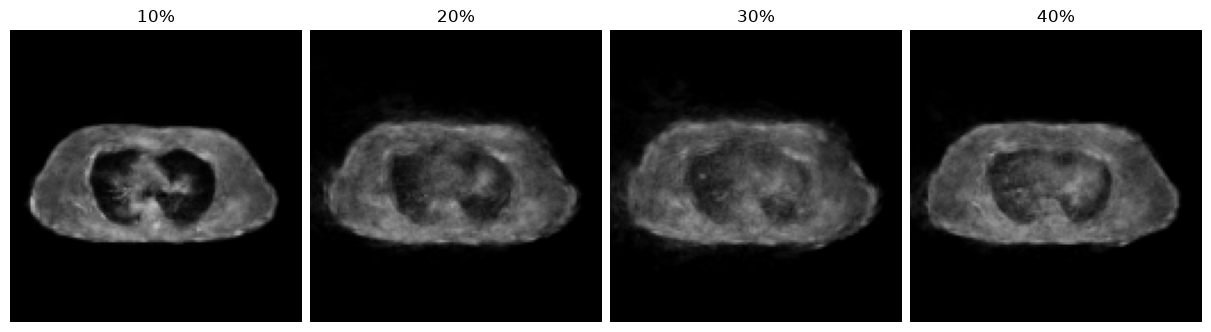

Displayed predicted phases: (10, 20, 30, 40)
Slice: 64
Saved: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/figures/118_0/hidden_phase_predictions_slice64.png


In [20]:
slice_index = 64
phases = (10, 20, 30, 40)

figure, axes = plt.subplots(
    1,
    len(phases),
    figsize=(12, 3.2),
    constrained_layout=True,
)

for axis, phase in zip(axes, phases):
    image = predictions[phase][:, :, slice_index].T

    axis.imshow(
        image,
        cmap="gray",
        vmin=0.0,
        vmax=1.0,
    )
    axis.set_title(f"{phase}%")
    axis.axis("off")

output_path = (
        OUTPUT_DIR
        / "figures"
        / CASE
        / "hidden_phase_predictions_slice64.png"
)

output_path.parent.mkdir(parents=True, exist_ok=True)

figure.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Displayed predicted phases:", phases)
print("Slice:", slice_index)
print("Saved:", output_path)

## 8. Pseudo-supervised temporal MedGS

The baseline MedGS4D model is constrained by the two observed respiratory states: the canonical representation at $0\%$ and the reconstructed endpoint at $50\%$.

Let $G_0$ denote the canonical Gaussian representation and let

$$
\Delta_{50} = \Delta_\theta(0.5)
$$

denote the deformation learned between the observed endpoint states.

For an intermediate respiratory phase $p \in [0,50]$, define

$$
\alpha(p) = \frac{p}{50}.
$$

We construct a virtual intermediate deformation by linear interpolation in deformation space:

$$
\Delta^{\mathrm{virt}}(p)
=
\alpha(p)\Delta_{50}.
$$

Hence,

$$
\Delta^{\mathrm{virt}}_{10}=0.2\Delta_{50},
\qquad
\Delta^{\mathrm{virt}}_{20}=0.4\Delta_{50},
$$

$$
\Delta^{\mathrm{virt}}_{30}=0.6\Delta_{50},
\qquad
\Delta^{\mathrm{virt}}_{40}=0.8\Delta_{50}.
$$

Conceptually:

    frame0
       │
       │ learn endpoint deformation
       ▼
    Δ50 from frame5
       │
       ├── 0.2 × Δ50 → virtual 10%
       ├── 0.4 × Δ50 → virtual 20%
       ├── 0.6 × Δ50 → virtual 30%
       └── 0.8 × Δ50 → virtual 40%

At an intermediate phase $p$, the deformation network predicts $\Delta_\theta(p)$.
We constrain this prediction toward the interpolated endpoint deformation:

$$
\mathcal{L}_{\mathrm{pseudo}}
=
\left\|
\widetilde{\Delta}_\theta(p)
-
\alpha(p)\,
\operatorname{sg}
\left(
\widetilde{\Delta}_{50}
\right)
\right\|_2^2,
$$

where $\operatorname{sg}$ denotes stop-gradient and $\widetilde{\Delta}$ denotes deformation expressed in normalized Gaussian coordinates.

The complete objective is

$$
\mathcal{L}
=
\mathcal{L}_{\mathrm{image},50}
+
\lambda_{\mathrm{pseudo}}\mathcal{L}_{\mathrm{pseudo}}
+
\lambda_{\mathrm{mag}}\mathcal{L}_{\mathrm{mag}}
+
\lambda_{\mathrm{smooth}}\mathcal{L}_{\mathrm{smooth}}.
$$

Only the observed $0\%$ and $50\%$ CT volumes are used. The ground-truth intermediate phases $10\%-40\%$ do not participate in optimization. Virtual intermediate states are generated dynamically in Gaussian deformation space and are not stored as images.

### 8.1 Instance-specific pseudo-supervision

The pseudo-supervised model remains instance-specific. No population-level pretraining is introduced.

For each benchmark series, the canonical representation is reconstructed from the observed 0% phase and the deformation model is optimized using the observed 50% endpoint. The only additional training signal is the virtual deformation constraint defined above.

The pseudo-supervision weight and training configuration are fixed before accessing the hidden 10%-40% ground-truth volumes.

In [22]:
PSEUDO_PHASES = (10.0, 20.0, 30.0, 40.0)
PSEUDO_WEIGHT = 0.1

PSEUDO_ROOT = OUTPUT_DIR / "dynamic_pseudo"

PSEUDO_RUN_NAME = (
    "phase00_to50_pseudo_iter7000"
)

print("Case:", CASE)
print("Virtual phases:", PSEUDO_PHASES)
print("Pseudo weight:", PSEUDO_WEIGHT)
print("Output:", PSEUDO_ROOT / f"benchmark_{CASE}" / PSEUDO_RUN_NAME)

Case: 118_0
Virtual phases: (10.0, 20.0, 30.0, 40.0)
Pseudo weight: 0.1
Output: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/dynamic_pseudo/benchmark_118_0/phase00_to50_pseudo_iter7000


### 8.2 Pseudo-supervised deformation training

The canonical MedGS representation remains frozen. The deformation network is optimized on the observed 50% endpoint exactly as in the baseline, with an additional constraint on virtual intermediate deformations.

At successive optimization steps, the pseudo-supervision coefficient cycles through

$$
\alpha \in \{0.2, 0.4, 0.6, 0.8\},
$$

corresponding to the 10%, 20%, 30%, and 40% positions between the observed endpoints.

The endpoint deformation is detached when constructing the virtual target. Consequently, the true 50% image remains the source of the endpoint deformation, while pseudo-supervision only constrains the shape of the trajectory between the canonical and endpoint states.

In [23]:


config_path = MEDGS4D_ROOT / "medgs4d" / "config.py"
training_path = MEDGS4D_ROOT / "medgs4d" / "training.py"
cli_path = MEDGS4D_ROOT / "scripts" / "train_medgs4d.py"


def replace_once(path, old, new):
    text = path.read_text(encoding="utf-8")
    assert text.count(old) == 1, (path, old)
    path.write_text(text.replace(old, new, 1), encoding="utf-8")


replace_once(
    config_path,
    """    smoothness_weight: float = 1e-3
    phase_jitter_initial_std: float = 0.0
""",
    """    smoothness_weight: float = 1e-3
    pseudo_weight: float = 0.0
    phase_jitter_initial_std: float = 0.0
""",
)

replace_once(
    config_path,
    """    if training.phase_jitter_initial_std < 0:
        raise ValueError("phase jitter standard deviation cannot be negative")
""",
    """    if training.phase_jitter_initial_std < 0:
        raise ValueError("phase jitter standard deviation cannot be negative")
    if training.pseudo_weight < 0:
        raise ValueError("pseudo_weight cannot be negative")
""",
)

replace_once(
    cli_path,
    """    parser.add_argument("--phase-jitter-std", type=float, default=0.0)
""",
    """    parser.add_argument("--phase-jitter-std", type=float, default=0.0)
    parser.add_argument("--pseudo-weight", type=float, default=0.0)
""",
)

replace_once(
    cli_path,
    """            seed=args.seed,
            phase_jitter_initial_std=args.phase_jitter_std,
""",
    """            seed=args.seed,
            phase_jitter_initial_std=args.phase_jitter_std,
            pseudo_weight=args.pseudo_weight,
""",
)

replace_once(
    training_path,
    """    return (first - second).square().mean()


def train_step(
""",
    """    return (first - second).square().mean()


def compute_pseudo_supervision_loss(
    field: DeformationField,
    endpoint_state: Mapping[str, torch.Tensor],
    gaussian_indices: torch.Tensor,
    *,
    endpoint_time: float,
    alpha: float,
) -> tuple[torch.Tensor, float]:
    \"\"\"Constrain an intermediate deformation toward the scaled endpoint deformation.\"\"\"

    canonical_time = field.canonical_phase / 100.0
    pseudo_time = canonical_time + alpha * (
        endpoint_time - canonical_time
    )

    pseudo_state = field.build_subset_state(
        pseudo_time,
        gaussian_indices,
    )

    target = (
        alpha
        * normalized_deformation(
            field,
            endpoint_state,
        ).detach()
    )

    prediction = normalized_deformation(
        field,
        pseudo_state,
    )

    loss = (prediction - target).square().mean()

    return loss, pseudo_time


def train_step(
""",
)

replace_once(
    training_path,
    """    smoothness = compute_temporal_smoothness_loss(
        field, current_subset, neighbor_subset
    )
    total = (
        image_loss
        + config.training.magnitude_weight * magnitude
        + config.training.smoothness_weight * smoothness
    )
""",
    """    smoothness = compute_temporal_smoothness_loss(
        field, current_subset, neighbor_subset
    )

    if config.training.pseudo_weight > 0:
        pseudo_alpha = (
            ((iteration - 1) % 4 + 1) / 5.0
        )
        pseudo_supervision, pseudo_time = (
            compute_pseudo_supervision_loss(
                field,
                current_subset,
                smoothness_indices,
                endpoint_time=respiratory_time,
                alpha=pseudo_alpha,
            )
        )
    else:
        pseudo_alpha = 0.0
        pseudo_time = field.canonical_phase / 100.0
        pseudo_supervision = torch.zeros(
            (),
            device=field.xyz.device,
            dtype=field.xyz.dtype,
        )

    total = (
        image_loss
        + config.training.magnitude_weight * magnitude
        + config.training.smoothness_weight * smoothness
        + config.training.pseudo_weight * pseudo_supervision
    )
""",
)

replace_once(
    training_path,
    """        "TemporalSmoothnessLoss": float(smoothness.detach().item()),
        "GradientNorm": gradient_norm,
""",
    """        "TemporalSmoothnessLoss": float(smoothness.detach().item()),
        "PseudoSupervisionLoss": float(
            pseudo_supervision.detach().item()
        ),
        "PseudoAlpha": pseudo_alpha,
        "PseudoPhasePercent": 100.0 * pseudo_time,
        "GradientNorm": gradient_norm,
""",
)

subprocess.run(
    [
        str(Path(sys.executable)),
        "-m",
        "compileall",
        "-q",
        str(MEDGS4D_ROOT / "medgs4d"),
        str(MEDGS4D_ROOT / "scripts"),
    ],
    check=True,
)

subprocess.run(
    [
        "git",
        "-C",
        str(MEDGS4D_ROOT),
        "diff",
        "--check",
    ],
    check=True,
)

print("Pseudo-supervision patch applied.")

Pseudo-supervision patch applied.


In [24]:
PSEUDO_WEIGHT = 0.1

PSEUDO_ROOT = OUTPUT_DIR / "dynamic_pseudo"
PSEUDO_RUN_NAME = "phase00_to50_pseudo_iter7000"

CANONICAL_RUN = (
        OUTPUT_DIR
        / "canonical"
        / f"benchmark_{CASE}"
        / "phase00_iter15000"
)

CANONICAL_CHECKPOINT = (
        CANONICAL_RUN
        / "model"
        / "chkpnt15000.pth"
)

print("Case:", CASE)
print("Pseudo weight:", PSEUDO_WEIGHT)
print("Run:", PSEUDO_RUN_NAME)

Case: 118_0
Pseudo weight: 0.1
Run: phase00_to50_pseudo_iter7000


In [25]:


command = [
    str(Path(sys.executable)),
    str(MEDGS4D_ROOT / "scripts" / "train_medgs4d.py"),
    "--data-dir", str(STUDY_DIR),
    "--canonical-model", str(CANONICAL_RUN),
    "--canonical-checkpoint", str(CANONICAL_CHECKPOINT),
    "--medgs-repo", str(MEDGS_REPO),
    "--output-root", str(PSEUDO_ROOT),
    "--run-name", PSEUDO_RUN_NAME,
    "--canonical-phase", "0",
    "--target-representation", "raw",
    "--split-mode", "full",
    "--iterations", "7000",
    "--learning-rate", "5e-4",
    "--checkpoint-every", "500",
    "--log-every", "25",
    "--validate-every", "0",
    "--validation-samples", "0",
    "--phase-jitter-std", "0",
    "--pseudo-weight", str(PSEUDO_WEIGHT),
    "--seed", "42",
    "--device", "cuda",
]

print("Starting pseudo-supervised training.")
print("Output:", PSEUDO_ROOT / f"benchmark_{CASE}" / PSEUDO_RUN_NAME)

subprocess.run(
    command,
    check=True,
)

print("Pseudo-supervised training completed.")

Starting pseudo-supervised training.
Output: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/dynamic_pseudo/benchmark_118_0/phase00_to50_pseudo_iter7000


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
Iteration 000025/007000 L1=0.112356 SSIM=0.795559 PSNR=13.186


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 000050/007000 L1=0.113524 SSIM=0.798721 PSNR=13.143


...

Iteration 006950/007000 L1=0.108141 SSIM=0.842999 PSNR=13.501


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 006975/007000 L1=0.106977 SSIM=0.841868 PSNR=13.589


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 007000/007000 L1=0.109169 SSIM=0.841891 PSNR=13.459
MedGS4D run: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/dynamic_pseudo/benchmark_118_0/phase00_to50_pseudo_iter7000
Pseudo-supervised training completed.


In [27]:


PSEUDO_RUN = (
        PSEUDO_ROOT
        / f"benchmark_{CASE}"
        / PSEUDO_RUN_NAME
)

pseudo_run = load_run(
    run_dir=PSEUDO_RUN,
)

history = pseudo_run.training_history

display(
    history[
        [
            "Iteration",
            "L1",
            "SSIM",
            "PSNR",
            "ImageLoss",
            "PseudoSupervisionLoss",
            "PseudoAlpha",
            "PseudoPhasePercent",
        ]
    ].tail(16)
)

pseudo_phases = sorted(
    history["PseudoPhasePercent"]
    .dropna()
    .unique()
)

assert np.allclose(
    pseudo_phases,
    [10.0, 20.0, 30.0, 40.0],
)

saved_config = json.loads(
    (PSEUDO_RUN / "config.json").read_text()
)

pseudo_weight = saved_config["training"]["pseudo_weight"]

print("Iterations:", len(history))
print("Pseudo weight:", pseudo_weight)
print("Pseudo phases:", pseudo_phases)

,Iteration,L1,SSIM,PSNR,ImageLoss,PseudoSupervisionLoss,PseudoAlpha,PseudoPhasePercent
6984,6985,0.085394,0.863431,14.913306,0.204930,0.000089,0.2,10.0
6985,6986,0.130340,0.822252,12.499076,0.305118,0.000058,0.4,20.0
6986,6987,0.085484,0.866992,14.711255,0.204221,0.000064,0.6,30.0
6987,6988,0.088182,0.849877,14.763618,0.213895,0.000087,0.8,40.0
6988,6989,0.111613,0.842810,13.357822,0.262524,0.000092,0.2,10.0
6989,6990,0.131967,0.804006,11.782858,0.312932,0.000060,0.4,20.0
6990,6991,0.128833,0.825339,12.575529,0.301330,0.000064,0.6,30.0
6991,6992,0.095732,0.854194,14.376553,0.227916,0.000083,0.8,40.0
6992,6993,0.119285,0.834241,13.024666,0.280009,0.000085,0.2,10.0
6993,6994,0.124668,0.827771,12.790860,0.292393,0.000058,0.4,20.0


Iterations: 7000
Pseudo weight: 0.1
Pseudo phases: [10.0, 20.0, 30.0, 40.0]


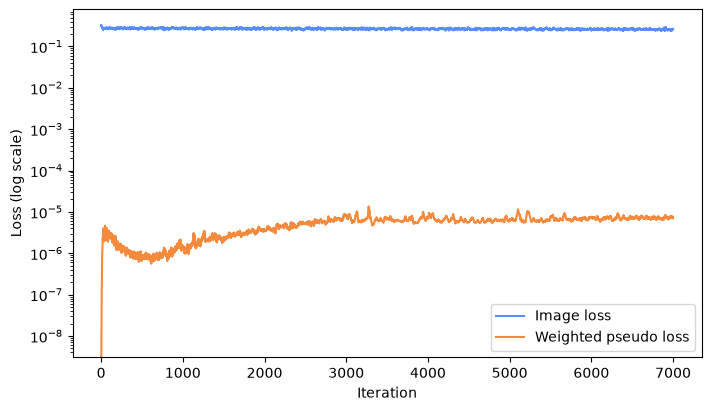

Mean image loss: 0.26715499315943037
Mean weighted pseudo loss: 5.192438870260159e-06
Saved: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/figures/118_0/pseudo_training_losses.png


In [33]:
weighted_pseudo = (
        pseudo_weight
        * history["PseudoSupervisionLoss"]
)

rolling = 10

figure, axis = plt.subplots(
    figsize=(7, 4),
    constrained_layout=True,
)

axis.plot(
    history["Iteration"],
    history["ImageLoss"].rolling(
        rolling,
        min_periods=1,
    ).mean(),
    label="Image loss",
)

axis.plot(
    history["Iteration"],
    weighted_pseudo.rolling(
        rolling,
        min_periods=1,
    ).mean(),
    label="Weighted pseudo loss",
)

axis.set_yscale("log")
axis.set_xlabel("Iteration")
axis.set_ylabel("Loss (log scale)")
axis.legend()

output_path = (
        OUTPUT_DIR
        / "figures"
        / CASE
        / "pseudo_training_losses.png"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Mean image loss:",
    history["ImageLoss"].mean(),
)
print(
    "Mean weighted pseudo loss:",
    weighted_pseudo.mean(),
)
print(
    "Saved:",
    output_path,
)

In [34]:
baseline_run = load_run(
    run_dir=DYNAMIC_RUN,
)

pseudo_run = load_run(
    run_dir=PSEUDO_RUN,
)

baseline_50 = (
    baseline_run.per_phase_metrics
    .loc[
        np.isclose(
            baseline_run.per_phase_metrics["PhasePercent"],
            50.0,
        )
    ]
    .iloc[0]
)

pseudo_50 = (
    pseudo_run.per_phase_metrics
    .loc[
        np.isclose(
            pseudo_run.per_phase_metrics["PhasePercent"],
            50.0,
        )
    ]
    .iloc[0]
)

comparison_50 = pd.DataFrame(
    {
        "Metric": [
            "L1",
            "PSNR",
            "SSIM",
        ],
        "Baseline": [
            baseline_50["DynamicL1"],
            baseline_50["DynamicPSNR"],
            baseline_50["DynamicSSIM"],
        ],
        "Pseudo": [
            pseudo_50["DynamicL1"],
            pseudo_50["DynamicPSNR"],
            pseudo_50["DynamicSSIM"],
        ],
    }
)

comparison_50["Pseudo - Baseline"] = (
        comparison_50["Pseudo"]
        - comparison_50["Baseline"]
)

display(comparison_50)

print("Observed 50% endpoint: baseline vs pseudo reconstruction")

,Metric,Baseline,Pseudo,Pseudo - Baseline
0,L1,0.109699,0.109665,-0.000034
1,PSNR,13.443771,13.442223,-0.001549
2,SSIM,0.842573,0.842463,-0.000110


Observed 50% endpoint: baseline vs pseudo reconstruction


In [35]:
PSEUDO_CHECKPOINT = (
        PSEUDO_RUN
        / "checkpoints"
        / "deformation_iter_007000.pth"
)

pseudo_canonical, pseudo_field = load_run_models(
    pseudo_run,
    checkpoint=PSEUDO_CHECKPOINT,
    device="cuda",
)


def render_model_phase(
        run,
        canonical,
        field,
        phase,
):
    """Render one phase as an (X, Y, Z) volume."""

    slices = []

    with torch.no_grad():
        gaussians, _ = field.build_phase_state(
            phase / 100.0,
            use_checkpointing=False,
        )

        for slice_index in range(
                run.study.slice_count
        ):
            camera = get_camera_for_slice(
                canonical,
                slice_index,
            )

            image = canonical.runtime.render(
                camera,
                gaussians,
                canonical.pipeline,
                canonical.background,
            )["render"]

            gray = (
                image
                .clamp(0, 1)
                .mean(dim=0)
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            slices.append(gray)

    volume_zyx = np.stack(
        slices,
        axis=0,
    )

    return np.transpose(
        volume_zyx,
        (2, 1, 0),
    )


print("Loaded:", PSEUDO_CHECKPOINT)

Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
Loaded: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/dynamic_pseudo/benchmark_118_0/phase00_to50_pseudo_iter7000/checkpoints/deformation_iter_007000.pth


In [31]:
PSEUDO_PREDICTIONS_DIR = (
        OUTPUT_DIR
        / "predictions_pseudo"
        / CASE
)

PSEUDO_PREDICTIONS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

pseudo_predictions = {}

for phase in (10, 20, 30, 40):
    prediction = render_model_phase(
        pseudo_run,
        pseudo_canonical,
        pseudo_field,
        phase,
    )

    pseudo_predictions[phase] = prediction

    np.save(
        PSEUDO_PREDICTIONS_DIR
        / f"phase_{phase:02d}.npy",
        prediction,
    )

    print(
        f"{phase}%:",
        prediction.shape,
    )

10%: (128, 128, 128)
20%: (128, 128, 128)
30%: (128, 128, 128)
40%: (128, 128, 128)


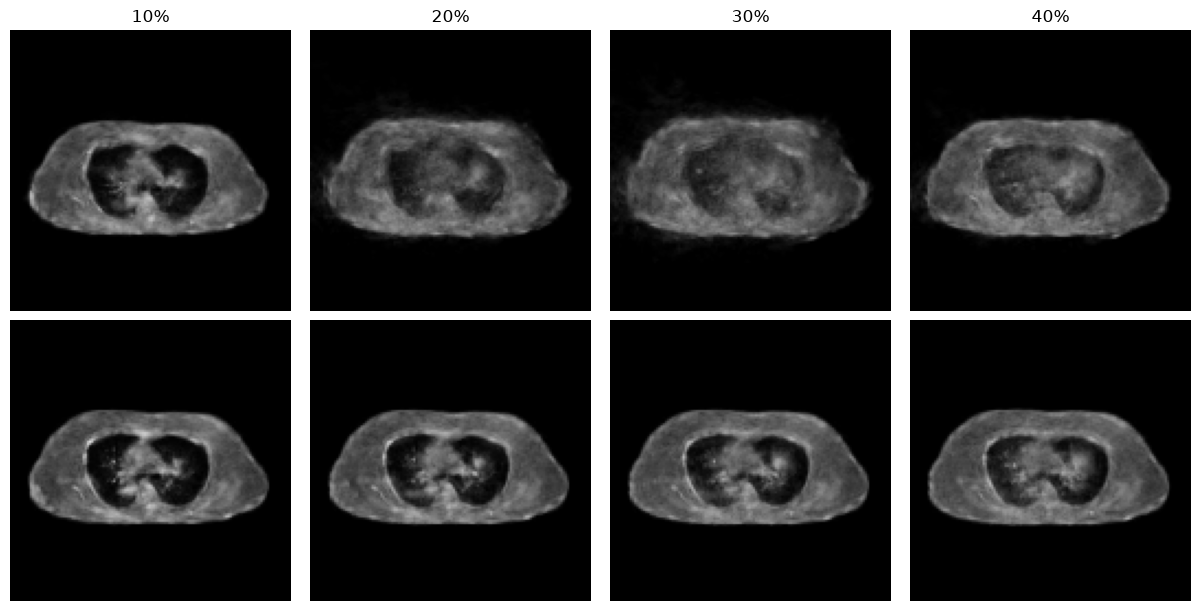

Compared phases: (10, 20, 30, 40)
Slice: 64
Saved: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/figures/118_0/baseline_vs_pseudo_hidden_slice64.png


In [32]:
baseline_predictions = {
    phase: np.load(
        OUTPUT_DIR
        / "predictions"
        / CASE
        / f"phase_{phase:02d}.npy"
    )
    for phase in (10, 20, 30, 40)
}

slice_index = 64
phases = (10, 20, 30, 40)

figure, axes = plt.subplots(
    2,
    len(phases),
    figsize=(12, 6),
    constrained_layout=True,
)

for column, phase in enumerate(phases):
    axes[0, column].imshow(
        baseline_predictions[phase][
            :, :, slice_index
        ].T,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[1, column].imshow(
        pseudo_predictions[phase][
            :, :, slice_index
        ].T,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[0, column].set_title(
        f"{phase}%"
    )

    axes[0, column].axis("off")
    axes[1, column].axis("off")

axes[0, 0].set_ylabel("Baseline")
axes[1, 0].set_ylabel("Pseudo")

output_path = (
        OUTPUT_DIR
        / "figures"
        / CASE
        / "baseline_vs_pseudo_hidden_slice64.png"
)

figure.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Compared phases:", phases)
print("Slice:", slice_index)
print("Saved:", output_path)

### 8.3 Hidden-phase evaluation

The pseudo-supervised model is now frozen. The previously unseen ground-truth volumes at 10%, 20%, 30%, and 40% are loaded only for evaluation.

Baseline and pseudo-supervised predictions are compared against the corresponding ground truth using the full-volume PSNR, NCC, SSIM, and NMSE metrics from the UVI-Net evaluation protocol. No hidden-phase ground truth was used during training or model selection.

In [4]:



def gaussian_1d(window_size=11, sigma=1.5):
    values = torch.tensor([
        math.exp(
            -((x - window_size // 2) ** 2)
            / (2 * sigma ** 2)
        )
        for x in range(window_size)
    ])
    return values / values.sum()


def ssim3d(original, generated, window_size=11):
    one_d = gaussian_1d(window_size).to(
        original.device,
        original.dtype,
    )

    two_d = one_d[:, None] * one_d[None, :]
    window = (
            one_d[:, None, None]
            * two_d[None, :, :]
    )

    window = window[
        None, None, ...
    ]

    padding = window_size // 2

    mu1 = F.conv3d(
        original,
        window,
        padding=padding,
    )
    mu2 = F.conv3d(
        generated,
        window,
        padding=padding,
    )

    mu1_sq = mu1.square()
    mu2_sq = mu2.square()
    mu12 = mu1 * mu2

    sigma1_sq = (
            F.conv3d(
                original.square(),
                window,
                padding=padding,
            )
            - mu1_sq
    )

    sigma2_sq = (
            F.conv3d(
                generated.square(),
                window,
                padding=padding,
            )
            - mu2_sq
    )

    sigma12 = (
            F.conv3d(
                original * generated,
                window,
                padding=padding,
            )
            - mu12
    )

    c1 = 0.01 ** 2
    c2 = 0.03 ** 2

    score = (
            (2 * mu12 + c1)
            * (2 * sigma12 + c2)
            / (
                    (mu1_sq + mu2_sq + c1)
                    * (sigma1_sq + sigma2_sq + c2)
            )
    )

    return score.mean()


def ncc3d(original, generated, window_size=9):
    window = torch.ones(
        1,
        1,
        window_size,
        window_size,
        window_size,
        device=original.device,
        dtype=original.dtype,
    )

    padding = window_size // 2
    window_volume = window_size ** 3

    original_sum = F.conv3d(
        original,
        window,
        padding=padding,
    )
    generated_sum = F.conv3d(
        generated,
        window,
        padding=padding,
    )

    original_sq_sum = F.conv3d(
        original.square(),
        window,
        padding=padding,
    )
    generated_sq_sum = F.conv3d(
        generated.square(),
        window,
        padding=padding,
    )

    cross_sum = F.conv3d(
        original * generated,
        window,
        padding=padding,
    )

    mean_original = (
            original_sum / window_volume
    )
    mean_generated = (
            generated_sum / window_volume
    )

    cross = (
            cross_sum
            - mean_generated * original_sum
            - mean_original * generated_sum
            + mean_original
            * mean_generated
            * window_volume
    )

    var_original = (
            original_sq_sum
            - 2 * mean_original * original_sum
            + mean_original.square()
            * window_volume
    )

    var_generated = (
            generated_sq_sum
            - 2 * mean_generated * generated_sum
            + mean_generated.square()
            * window_volume
    )

    return (
            cross.square()
            / (
                    var_original
                    * var_generated
                    + 1e-5
            )
    ).mean()


def evaluate_volume(gt, prediction):
    gt_tensor = torch.from_numpy(
        gt.astype(np.float32)
    )[None, None].cuda()

    prediction_tensor = torch.from_numpy(
        prediction.astype(np.float32)
    )[None, None].cuda()

    mse = torch.mean(
        (gt_tensor - prediction_tensor) ** 2
    )

    psnr = (
            20
            * torch.log10(
        1.0 / torch.sqrt(mse)
    )
    )

    nmse = (
            mse
            / torch.mean(gt_tensor ** 2)
    )

    return {
        "PSNR": float(psnr),
        "NCC": float(
            ncc3d(
                gt_tensor,
                prediction_tensor,
            )
        ),
        "SSIM": float(
            ssim3d(
                gt_tensor,
                prediction_tensor,
            )
        ),
        "NMSE": float(nmse * 100),
    }


In [36]:

rows = []

for phase in (10, 20, 30, 40):
    frame = phase // 10

    gt_path = (
            DATA_ROOT
            / CASE
            / f"ct_{CASE}_frame{frame}.nii.gz"
    )

    gt = nib.load(
        gt_path
    ).get_fdata().astype(np.float32)

    for method, prediction in (
            (
                    "Baseline",
                    baseline_predictions[phase],
            ),
            (
                    "Pseudo",
                    pseudo_predictions[phase],
            ),
    ):
        metrics = evaluate_volume(
            gt,
            prediction,
        )

        rows.append({
            "PhasePercent": phase,
            "Method": method,
            **metrics,
        })

hidden_metrics = pd.DataFrame(rows)

display(hidden_metrics)

print(
    "Evaluated hidden ground-truth phases: "
    "10%, 20%, 30%, 40%."
)

,PhasePercent,Method,PSNR,NCC,SSIM,NMSE
0,10,Baseline,13.302965,0.208415,0.789003,28.955988
1,10,Pseudo,13.369953,0.230124,0.800965,28.512774
2,20,Baseline,12.845823,0.159579,0.705738,32.007809
3,20,Pseudo,13.415060,0.240551,0.814878,28.075817
4,30,Baseline,12.551905,0.139848,0.659911,34.084076
5,30,Pseudo,13.422892,0.247108,0.826150,27.890280
6,40,Baseline,13.008505,0.181728,0.764419,30.540075
7,40,Pseudo,13.396997,0.250024,0.836061,27.926783


Evaluated hidden ground-truth phases: 10%, 20%, 30%, 40%.


## 9. Pseudo-cyclic MedGS

The next variant extends linear pseudo-supervision with endpoint cycle consistency.

For an intermediate respiratory time $t$, the deformation model first predicts an intermediate Gaussian state

$$
\Theta_t = T_\theta(\Theta_0, t).
$$

The same deformation network is then reused as a pairwise transport model starting from the intermediate geometry. Two cyclic reconstructions are produced:

$$
\hat{\Theta}_0^{cyc}
=
T_\theta(\Theta_t, t \rightarrow 0),
$$

and

$$
\hat{\Theta}_{50}^{cyc}
=
T_\theta(\Theta_t, t \rightarrow 0.5).
$$

Both states are rendered and compared only with the two observed endpoint images:

$$
L_{cyc}
=
\frac{1}{2}
\left[
L_{img}(R(\hat{\Theta}_0^{cyc}), I_0)
+
L_{img}(R(\hat{\Theta}_{50}^{cyc}), I_{50})
\right].
$$

The complete objective is

$$
L
=
L_{MedGS4D}
+
\lambda_{pseudo} L_{pseudo}
+
\lambda_{cyc} L_{cyc},
$$

with

$$
\lambda_{pseudo}=0.1,
\qquad
\lambda_{cyc}=0.1.
$$

The hidden 10%-40% ground-truth volumes are not used by the cyclic loss. The cyclic constraint therefore provides additional supervision exclusively through reconstruction of the observed endpoints.

This is a minimal Gaussian-space adaptation of the cycle-consistency principle used by UVI-Net, rather than a reproduction of the UVI-Net architecture.

In [5]:


REPO_ROOT = STACK_ROOT / "repo" / "medgs4d"

CONFIG_PATH = REPO_ROOT / "medgs4d" / "config.py"
TRAINING_PATH = REPO_ROOT / "medgs4d" / "training.py"
CLI_PATH = REPO_ROOT / "scripts" / "train_medgs4d.py"

In [37]:

# ---------------------------------------------------------
# config.py
# ---------------------------------------------------------

source = CONFIG_PATH.read_text(encoding="utf-8")

if "cycle_weight: float = 0.0" not in source:
    assert "pseudo_weight: float = 0.0" in source

    source = source.replace(
        "    pseudo_weight: float = 0.0\n",
        "    pseudo_weight: float = 0.0\n"
        "    cycle_weight: float = 0.0\n",
        1,
    )

    assert "    if training.pseudo_weight < 0:\n" in source

    source = source.replace(
        "    if training.pseudo_weight < 0:\n",
        "    if training.cycle_weight < 0:\n"
        '        raise ValueError("cycle_weight must be non-negative")\n'
        "    if training.pseudo_weight < 0:\n",
        1,
    )

    CONFIG_PATH.write_text(
        source,
        encoding="utf-8",
    )

# ---------------------------------------------------------
# train_medgs4d.py
# ---------------------------------------------------------

source = CLI_PATH.read_text(encoding="utf-8")

if "--cycle-weight" not in source:
    anchor = (
        '    parser.add_argument('
        '"--pseudo-weight", '
        "type=float, "
        "default=0.0"
        ")\n"
    )

    assert anchor in source

    source = source.replace(
        anchor,
        anchor
        + '    parser.add_argument('
          '"--cycle-weight", '
          "type=float, "
          "default=0.0"
          ")\n",
        1,
    )

    anchor = (
        "            pseudo_weight="
        "args.pseudo_weight,\n"
    )

    assert anchor in source

    source = source.replace(
        anchor,
        anchor
        + "            cycle_weight="
          "args.cycle_weight,\n",
        1,
    )

    CLI_PATH.write_text(
        source,
        encoding="utf-8",
    )

# ---------------------------------------------------------
# training.py
# ---------------------------------------------------------

source = TRAINING_PATH.read_text(
    encoding="utf-8"
)

if "def build_pairwise_phase_view(" not in source:
    source = source.replace(
        "import torch\n",
        "import torch\n"
        "from torch.utils.checkpoint "
        "import checkpoint\n",
        1,
    )

    source = source.replace(
        "from .deformation import "
        "DeformationField\n",
        "from .deformation import "
        "DeformationField, "
        "PhaseDeformedGaussianView\n",
        1,
    )

    helper_code = r'''
def build_pairwise_phase_view(
    field: DeformationField,
    source_state: Mapping[str, torch.Tensor],
    *,
    source_time: float,
    target_time: float,
) -> PhaseDeformedGaussianView:
    """Transport a dynamic Gaussian state between two respiratory times."""

    source_xz = (
        field.xz
        + source_state["delta_xz"]
    )

    source_m_logits = (
        field.m_logits
        + source_state["delta_m_logit"]
    )

    source_m = torch.sigmoid(
        source_m_logits
    )

    normalized_coordinates = torch.cat(
        [
            (
                source_xz
                - field.xz_mean
            )
            / field.xz_scale,
            (
                source_m
                - field.m_mean
            )
            / field.m_scale,
        ],
        dim=-1,
    )

    spatial_features = (
        field.encode_spatial_coordinates(
            normalized_coordinates
        )
    )

    chunks = []

    for start in range(
        0,
        spatial_features.shape[0],
        field.config.chunk_size,
    ):
        selected = spatial_features[
            start:
            start + field.config.chunk_size
        ]

        target_inputs = (
            field.build_mlp_inputs(
                selected,
                target_time,
            )
        )

        source_inputs = (
            field.build_mlp_inputs(
                selected,
                source_time,
            )
        )

        joint_inputs = torch.cat(
            [
                target_inputs,
                source_inputs,
            ],
            dim=0,
        )

        outputs = checkpoint(
            field.model,
            joint_inputs,
            use_reentrant=False,
        )

        count = selected.shape[0]

        chunks.append(
            outputs[:count]
            - outputs[count:]
        )

    pairwise_delta = torch.cat(
        chunks,
        dim=0,
    )

    target_xz = (
        source_xz
        + pairwise_delta[:, :2]
    )

    target_m_logits = (
        source_m_logits
        + pairwise_delta[:, 2:3]
    )

    target_m = torch.sigmoid(
        target_m_logits
    )

    target_xyz = torch.stack(
        [
            target_xz[:, 0],
            field.xyz[:, 1],
            target_xz[:, 1],
        ],
        dim=-1,
    )

    return PhaseDeformedGaussianView(
        field.canonical.gaussians,
        target_xyz,
        target_m,
    )


def compute_cyclic_reconstruction_loss(
    canonical: CanonicalAssets,
    field: DeformationField,
    study: StudyManifest,
    camera,
    endpoint_target: torch.Tensor,
    source_state: Mapping[str, torch.Tensor],
    *,
    source_time: float,
    endpoint_phase: float,
    slice_index: int,
    config: MedGS4DConfig,
    iteration: int,
) -> tuple[
    torch.Tensor,
    torch.Tensor,
    torch.Tensor,
]:
    """Reconstruct both observed endpoints from one intermediate state."""

    canonical_time = (
        field.canonical_phase / 100.0
    )

    endpoint_time = (
        endpoint_phase / 100.0
    )

    canonical_view = (
        build_pairwise_phase_view(
            field,
            source_state,
            source_time=source_time,
            target_time=canonical_time,
        )
    )

    endpoint_view = (
        build_pairwise_phase_view(
            field,
            source_state,
            source_time=source_time,
            target_time=endpoint_time,
        )
    )

    canonical_render = (
        canonical.runtime.render(
            camera,
            canonical_view,
            canonical.pipeline,
            canonical.background,
            train=True,
            iter=iteration,
        )["render"]
    )

    endpoint_render = (
        canonical.runtime.render(
            camera,
            endpoint_view,
            canonical.pipeline,
            canonical.background,
            train=True,
            iter=iteration,
        )["render"]
    )

    canonical_target = load_target_tensor(
        study,
        field.canonical_phase,
        slice_index,
        representation=(
            config.target_representation
        ),
        device=str(field.xyz.device),
    )

    canonical_loss, _ = (
        compute_reconstruction_loss(
            canonical,
            canonical_render,
            canonical_target,
            l1_weight=(
                config.training.l1_weight
            ),
            ssim_weight=(
                config.training.ssim_weight
            ),
        )
    )

    endpoint_loss, _ = (
        compute_reconstruction_loss(
            canonical,
            endpoint_render,
            endpoint_target,
            l1_weight=(
                config.training.l1_weight
            ),
            ssim_weight=(
                config.training.ssim_weight
            ),
        )
    )

    cycle_loss = 0.5 * (
        canonical_loss
        + endpoint_loss
    )

    return (
        cycle_loss,
        canonical_loss,
        endpoint_loss,
    )


'''

    anchor = "\ndef train_step(\n"
    assert anchor in source

    source = source.replace(
        anchor,
        "\n" + helper_code + anchor,
        1,
    )

if "CyclicReconstructionLoss" not in source:
    train_start = source.index(
        "def train_step("
    )

    block_start = source.index(
        "    if config.training."
        "pseudo_weight > 0:\n",
        train_start,
    )

    block_end = source.index(
        "    total = (\n",
        block_start,
    )

    virtual_block = r'''    virtual_supervision = (
        config.training.pseudo_weight > 0
        or config.training.cycle_weight > 0
    )

    if virtual_supervision:
        pseudo_alpha = (
            ((iteration - 1) % 4 + 1)
            / 5.0
        )

        canonical_time = (
            field.canonical_phase
            / 100.0
        )

        pseudo_time = (
            canonical_time
            + pseudo_alpha
            * (
                respiratory_time
                - canonical_time
            )
        )
    else:
        pseudo_alpha = float("nan")
        pseudo_time = float("nan")

    if config.training.pseudo_weight > 0:
        (
            pseudo_supervision,
            _,
        ) = compute_pseudo_supervision_loss(
            field,
            current_subset,
            smoothness_indices,
            endpoint_time=respiratory_time,
            alpha=pseudo_alpha,
        )
    else:
        pseudo_supervision = torch.zeros(
            (),
            device=field.xyz.device,
            dtype=field.xyz.dtype,
        )

    if config.training.cycle_weight > 0:
        (
            _,
            pseudo_full_state,
        ) = field.build_phase_state(
            pseudo_time,
            use_checkpointing=True,
        )

        (
            cyclic_reconstruction,
            cycle_canonical_loss,
            cycle_endpoint_loss,
        ) = compute_cyclic_reconstruction_loss(
            canonical,
            field,
            study,
            camera,
            target,
            pseudo_full_state,
            source_time=pseudo_time,
            endpoint_phase=phase,
            slice_index=slice_index,
            config=config,
            iteration=iteration,
        )
    else:
        cyclic_reconstruction = torch.zeros(
            (),
            device=field.xyz.device,
            dtype=field.xyz.dtype,
        )

        cycle_canonical_loss = (
            cyclic_reconstruction
        )

        cycle_endpoint_loss = (
            cyclic_reconstruction
        )

'''

    source = (
            source[:block_start]
            + virtual_block
            + source[block_end:]
    )

    total_anchor = (
        "        + config.training."
        "pseudo_weight "
        "* pseudo_supervision\n"
    )

    assert total_anchor in source

    source = source.replace(
        total_anchor,
        total_anchor
        + "        + config.training."
          "cycle_weight "
          "* cyclic_reconstruction\n",
        1,
    )

    history_anchor = (
        '        "GradientNorm": '
        "gradient_norm,\n"
    )

    assert history_anchor in source

    source = source.replace(
        history_anchor,
        '        "CyclicReconstructionLoss": '
        "float("
        "cyclic_reconstruction.detach().item()"
        "),\n"
        '        "CycleCanonicalImageLoss": '
        "float("
        "cycle_canonical_loss.detach().item()"
        "),\n"
        '        "CycleEndpointImageLoss": '
        "float("
        "cycle_endpoint_loss.detach().item()"
        "),\n"
        + history_anchor,
        1,
    )

    TRAINING_PATH.write_text(
        source,
        encoding="utf-8",
    )

subprocess.run(
    [
        str(Path(sys.executable)),
        "-m",
        "compileall",
        "-q",
        "medgs4d",
        "scripts",
    ],
    cwd=REPO_ROOT,
    check=True,
)

subprocess.run(
    [
        "git",
        "diff",
        "--check",
    ],
    cwd=REPO_ROOT,
    check=True,
)

print(
    "Pseudo-cyclic training patch applied."
)

Pseudo-cyclic training patch applied.


In [39]:


training_env = os.environ.copy()
training_env["CUDA_VISIBLE_DEVICES"] = "1"
training_env["PYTORCH_CUDA_ALLOC_CONF"] = (
    "expandable_segments:True"
)

CYCLE_WEIGHT = 0.1

CYCLIC_ROOT = (
        OUTPUT_DIR
        / "dynamic_pseudo_cyclic"
)

CYCLIC_RUN_NAME = (
    "phase00_to50_pseudo_cyclic_iter7000"
)

reference_config = json.loads(
    (PSEUDO_RUN / "config.json").read_text()
)

canonical_checkpoint = (
        OUTPUT_DIR
        / "canonical"
        / f"benchmark_{CASE}"
        / "phase00_iter15000"
        / "model"
        / "chkpnt15000.pth"
)

command = [
    str(Path(sys.executable)),
    str(
        REPO_ROOT
        / "scripts"
        / "train_medgs4d.py"
    ),
    "--data-dir",
    reference_config["data_dir"],
    "--canonical-model",
    reference_config[
        "canonical_model_dir"
    ],
    "--canonical-checkpoint",
    str(canonical_checkpoint),
    "--medgs-repo",
    reference_config[
        "medgs_repository"
    ],
    "--output-root",
    str(CYCLIC_ROOT),
    "--run-name",
    CYCLIC_RUN_NAME,
    "--canonical-phase",
    "0",
    "--target-representation",
    "raw",
    "--split-mode",
    "full",
    "--iterations",
    "7000",
    "--learning-rate",
    "0.0005",
    "--spatial-frequencies",
    "4",
    "--phase-frequencies",
    "2",
    "--hidden-dim",
    "256",
    "--hidden-layers",
    "4",
    "--chunk-size",
    "131072",
    "--checkpoint-every",
    "500",
    "--log-every",
    "25",
    "--validate-every",
    "0",
    "--validation-samples",
    "0",
    "--seed",
    "42",
    "--phase-jitter-std",
    "0",
    "--pseudo-weight",
    "0.1",
    "--cycle-weight",
    str(CYCLE_WEIGHT),
    "--force",
    "--device",
    "cuda",
]

print(
    "Starting pseudo-cyclic training."
)

# subprocess.run(
#     command,
#     cwd=REPO_ROOT,
#     check=True,
# )
subprocess.run(
    command,
    cwd=REPO_ROOT,
    check=True,
    env=training_env,
)

print(
    "Pseudo-cyclic training completed."
)

Starting pseudo-cyclic training.


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
Iteration 000025/007000 L1=0.112354 SSIM=0.795550 PSNR=13.186


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 000050/007000 L1=0.113525 SSIM=0.798719 PSNR=13.143


...

Iteration 006950/007000 L1=0.108085 SSIM=0.844380 PSNR=13.510


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 006975/007000 L1=0.106898 SSIM=0.843293 PSNR=13.600


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 007000/007000 L1=0.109239 SSIM=0.840750 PSNR=13.457
MedGS4D run: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/dynamic_pseudo_cyclic/benchmark_118_0/phase00_to50_pseudo_cyclic_iter7000
Pseudo-cyclic training completed.


### 9.1 Pseudo-cyclic training sanity check

The completed pseudo-cyclic run is loaded and its training losses and observed 50% endpoint reconstruction are inspected before evaluating the intermediate phases.

In [41]:



CYCLIC_RUN = (
        OUTPUT_DIR
        / "dynamic_pseudo_cyclic"
        / f"benchmark_{CASE}"
        / "phase00_to50_pseudo_cyclic_iter7000"
)

cyclic_run = load_run(
    run_dir=CYCLIC_RUN
)

cyclic_history = (
    cyclic_run.training_history
)

display(
    cyclic_history[
        [
            "Iteration",
            "ImageLoss",
            "PseudoSupervisionLoss",
            "CyclicReconstructionLoss",
            "CycleCanonicalImageLoss",
            "CycleEndpointImageLoss",
        ]
    ].tail(16)
)

cyclic_phase_metrics = (
    cyclic_run.per_phase_metrics
)

display(
    cyclic_phase_metrics[
        cyclic_phase_metrics[
            "PhasePercent"
        ].eq(50)
    ][
        [
            "PhasePercent",
            "DynamicL1",
            "DynamicPSNR",
            "DynamicSSIM",
        ]
    ]
)

print(
    "Loaded completed pseudo-cyclic run."
)

,Iteration,ImageLoss,PseudoSupervisionLoss,CyclicReconstructionLoss,CycleCanonicalImageLoss,CycleEndpointImageLoss
6984,6985,0.205731,0.000405,0.213735,0.220719,0.206752
6985,6986,0.304687,0.000675,0.310476,0.310891,0.310060
6986,6987,0.204188,0.000453,0.208507,0.212105,0.204910
6987,6988,0.214816,0.000148,0.219850,0.224131,0.215569
6988,6989,0.263692,0.000436,0.266191,0.264656,0.267727
6989,6990,0.312856,0.000727,0.302429,0.295350,0.309507
6990,6991,0.302195,0.000474,0.305931,0.305302,0.306561
6991,6992,0.228426,0.000150,0.234022,0.238998,0.229045
6992,6993,0.281112,0.000417,0.289431,0.293347,0.285515
6993,6994,0.292552,0.000674,0.300191,0.304803,0.295579


,PhasePercent,DynamicL1,DynamicPSNR,DynamicSSIM
1,50.0,0.109722,13.447872,0.840676


Loaded completed pseudo-cyclic run.


### 9.2 Pseudo-cyclic intermediate predictions

The trained pseudo-cyclic model is rendered at the four benchmark interpolation phases: 10%, 20%, 30%, and 40%.

These predictions are generated with the same MedGS renderer and deformation model as the previous variants.

In [42]:

from medgs4d.canonical import (
    get_camera_for_slice,
)
from medgs4d.results import (
    load_run_models,
)

cyclic_canonical, cyclic_field = (
    load_run_models(
        cyclic_run,
        device="cuda",
    )
)

CYCLIC_PREDICTION_DIR = (
        OUTPUT_DIR
        / "predictions_pseudo_cyclic"
        / CASE
)

CYCLIC_PREDICTION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

cyclic_predictions = {}

for phase in (10, 20, 30, 40):
    slices = []

    with torch.no_grad():
        view, _ = (
            cyclic_field.build_phase_state(
                phase / 100.0,
                use_checkpointing=False,
            )
        )

        for slice_index in range(128):
            camera = get_camera_for_slice(
                cyclic_canonical,
                slice_index,
            )

            rendered = (
                cyclic_canonical.runtime.render(
                    camera,
                    view,
                    cyclic_canonical.pipeline,
                    cyclic_canonical.background,
                )["render"]
            )

            image = (
                rendered
                .clamp(0, 1)
                .mean(dim=0)
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            slices.append(image)

    volume = np.stack(
        slices,
        axis=0,
    )

    cyclic_predictions[phase] = volume

    output_path = (
            CYCLIC_PREDICTION_DIR
            / f"phase_{phase:02d}.npy"
    )

    np.save(
        output_path,
        volume,
    )

    print(
        f"Rendered {phase}%: "
        f"{volume.shape}"
    )

Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
Rendered 10%: (128, 128, 128)
Rendered 20%: (128, 128, 128)
Rendered 30%: (128, 128, 128)
Rendered 40%: (128, 128, 128)


### 9.3 Hidden-phase comparison

The baseline, linear pseudo-supervised, and pseudo-cyclic models are evaluated on the same previously unseen 10%, 20%, 30%, and 40% ground-truth volumes.

All three variants are compared using identical full-volume PSNR, NCC, SSIM, and NMSE calculations.

In [43]:
rows = []

for phase in (10, 20, 30, 40):
    frame = phase // 10

    gt_path = (
            DATA_ROOT
            / CASE
            / f"ct_{CASE}_frame{frame}.nii.gz"
    )

    gt = nib.load(
        gt_path
    ).get_fdata().astype(np.float32)

    predictions = (
        (
            "Baseline",
            baseline_predictions[phase],
        ),
        (
            "Linear pseudo",
            pseudo_predictions[phase],
        ),
        (
            "Pseudo-cyclic",
            cyclic_predictions[phase],
        ),
    )

    for method, prediction in predictions:
        metrics = evaluate_volume(
            gt,
            prediction,
        )

        rows.append({
            "PhasePercent": phase,
            "Method": method,
            **metrics,
        })

hidden_metrics_three = pd.DataFrame(rows)

display(hidden_metrics_three)

summary_three = (
    hidden_metrics_three
    .groupby("Method")[
        ["PSNR", "NCC", "SSIM", "NMSE"]
    ]
    .mean()
)

display(summary_three)

output_path = (
        OUTPUT_DIR
        / "evaluation"
        / CASE
        / "hidden_metrics_three_methods.csv"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

hidden_metrics_three.to_csv(
    output_path,
    index=False,
)

print(
    "Compared baseline, linear pseudo, and pseudo-cyclic "
    "on hidden phases 10%-40%."
)
print("Saved:", output_path)

,PhasePercent,Method,PSNR,NCC,SSIM,NMSE
0,10,Baseline,13.302965,0.208415,0.789003,28.955988
1,10,Linear pseudo,13.369953,0.230124,0.800965,28.512774
2,10,Pseudo-cyclic,10.475952,0.045295,0.620713,55.518745
3,20,Baseline,12.845823,0.159579,0.705738,32.007809
4,20,Linear pseudo,13.415060,0.240551,0.814878,28.075817
5,20,Pseudo-cyclic,10.542412,0.045711,0.621239,54.399784
6,30,Baseline,12.551905,0.139848,0.659911,34.084076
7,30,Linear pseudo,13.422892,0.247108,0.826150,27.890280
8,30,Pseudo-cyclic,10.565424,0.045910,0.622086,53.851734
9,40,Baseline,13.008505,0.181728,0.764419,30.540075


,PSNR,NCC,SSIM,NMSE
Method,,,,
Baseline,12.927299,0.172392,0.729768,31.396987
Linear pseudo,13.401226,0.241952,0.819514,28.101413
Pseudo-cyclic,10.541471,0.045647,0.621730,54.291644


Compared baseline, linear pseudo, and pseudo-cyclic on hidden phases 10%-40%.
Saved: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/evaluation/118_0/hidden_metrics_three_methods.csv


## 10. Pairwise pseudo-cyclic MedGS

The first pseudo-cyclic prototype reused the canonical-anchored deformation MLP as an arbitrary pairwise transport operator. This assumption was too restrictive and produced poor intermediate reconstructions.

The second cycle formulation introduces a separate auxiliary pairwise transport network

$$
T_\psi(\Theta_s, s, t),
$$

which predicts an incremental Gaussian deformation from an arbitrary source state at time $s$ to a target time $t$.

The primary MedGS4D deformation field remains unchanged and continues to generate the intermediate state used at inference. The pairwise network is used only as an auxiliary training mechanism.

Three normalized times are sampled:

$$
u_1 \in [-0.5, 0], \qquad
u_2 \in [0, 1], \qquad
u_3 \in [1, 1.5].
$$

The central state $\Theta_{u_2}$ is generated by the primary MedGS4D field. The outer states are virtual extrapolations derived from the observed endpoint deformation.

Four pairwise transports produce two independent candidates for each observed endpoint:

$$
\Theta_{u_1} \rightarrow \hat{\Theta}_0^{(1)},
\qquad
\Theta_{u_2} \rightarrow \hat{\Theta}_0^{(2)},
$$

and

$$
\Theta_{u_2} \rightarrow \hat{\Theta}_{50}^{(1)},
\qquad
\Theta_{u_3} \rightarrow \hat{\Theta}_{50}^{(2)}.
$$

The two candidates for each endpoint are combined in Gaussian parameter space and rendered using the original MedGS renderer.

The hidden 10%-40% ground-truth volumes are not used by this training objective.

In [44]:


REPO_ROOT = STACK_ROOT / "repo" / "medgs4d"
CYCLE_PATH = REPO_ROOT / "medgs4d" / "cycle.py"

cycle_source = r'''from __future__ import annotations

from dataclasses import dataclass
from typing import Mapping

import torch
from torch.utils.checkpoint import checkpoint

from .deformation import (
    DeformationField,
    PhaseDeformedGaussianView,
)


class PairwiseTransportMLP(torch.nn.Module):
    """Predict incremental Gaussian transport between two arbitrary times."""

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        hidden_layers: int,
    ) -> None:
        super().__init__()

        layers: list[torch.nn.Module] = []
        current_dim = input_dim

        for _ in range(hidden_layers):
            layers.extend(
                [
                    torch.nn.Linear(
                        current_dim,
                        hidden_dim,
                    ),
                    torch.nn.SiLU(),
                ]
            )
            current_dim = hidden_dim

        self.backbone = torch.nn.Sequential(
            *layers
        )

        self.output_layer = torch.nn.Linear(
            current_dim,
            3,
        )

        torch.nn.init.zeros_(
            self.output_layer.weight
        )
        torch.nn.init.zeros_(
            self.output_layer.bias
        )

    def forward(
        self,
        inputs: torch.Tensor,
    ) -> torch.Tensor:
        return self.output_layer(
            self.backbone(inputs)
        )


@dataclass
class PairwiseCycleOutput:
    """Store Gaussian states and regularizers produced by one cycle."""

    reconstructed_canonical: dict[str, torch.Tensor]
    reconstructed_endpoint: dict[str, torch.Tensor]

    canonical_candidate_left: dict[str, torch.Tensor]
    canonical_candidate_middle: dict[str, torch.Tensor]

    endpoint_candidate_middle: dict[str, torch.Tensor]
    endpoint_candidate_right: dict[str, torch.Tensor]

    agreement_loss: torch.Tensor
    transport_loss: torch.Tensor


def state_to_view(
    field: DeformationField,
    state: Mapping[str, torch.Tensor],
) -> PhaseDeformedGaussianView:
    """Convert one Gaussian deformation state to a renderer-compatible view."""

    return PhaseDeformedGaussianView(
        field.canonical.gaussians,
        state["dynamic_xyz"],
        state["dynamic_m"],
    )


class PairwiseTransport(torch.nn.Module):
    """Transport a dynamic Gaussian state between arbitrary local times."""

    def __init__(
        self,
        field: DeformationField,
        *,
        hidden_dim: int = 128,
        hidden_layers: int = 3,
        time_frequencies: int = 2,
    ) -> None:
        super().__init__()

        self.field = field
        self.time_frequencies = int(
            time_frequencies
        )

        spatial_dim = int(
            field.spatial_features.shape[1]
        )

        time_dim = (
            1
            + 2 * self.time_frequencies
        )

        self.model = PairwiseTransportMLP(
            input_dim=(
                spatial_dim
                + 2 * time_dim
            ),
            hidden_dim=hidden_dim,
            hidden_layers=hidden_layers,
        ).to(
            device=field.xyz.device,
            dtype=field.xyz.dtype,
        )

    @property
    def parameter_count(self) -> int:
        return sum(
            parameter.numel()
            for parameter
            in self.parameters()
        )

    def _encode_time(
        self,
        local_time: float,
    ) -> torch.Tensor:
        """Encode local cycle time without periodic wrapping."""

        value = torch.as_tensor(
            local_time,
            device=self.field.xyz.device,
            dtype=self.field.xyz.dtype,
        ).reshape(1)

        frequencies = (
            2.0
            ** torch.arange(
                self.time_frequencies,
                device=value.device,
                dtype=value.dtype,
            )
        )

        angles = (
            torch.pi
            * value.unsqueeze(-1)
            * frequencies
        )

        return torch.cat(
            [
                value,
                torch.sin(angles).flatten(),
                torch.cos(angles).flatten(),
            ],
            dim=0,
        )

    def _build_state(
        self,
        delta_xz: torch.Tensor,
        delta_m_logit: torch.Tensor,
    ) -> dict[str, torch.Tensor]:
        """Build a complete dynamic state from canonical-relative residuals."""

        dynamic_xz = (
            self.field.xz
            + delta_xz
        )

        dynamic_m = torch.sigmoid(
            self.field.m_logits
            + delta_m_logit
        )

        dynamic_xyz = torch.stack(
            [
                dynamic_xz[:, 0],
                self.field.xyz[:, 1],
                dynamic_xz[:, 1],
            ],
            dim=-1,
        )

        relative = torch.cat(
            [
                delta_xz,
                delta_m_logit,
            ],
            dim=-1,
        )

        return {
            "relative_deformation": relative,
            "delta_xz": delta_xz,
            "delta_m_logit": delta_m_logit,
            "delta_m": (
                dynamic_m
                - self.field.m
            ),
            "dynamic_xyz": dynamic_xyz,
            "dynamic_m": dynamic_m,
        }

    def virtual_state(
        self,
        endpoint_state: Mapping[
            str,
            torch.Tensor,
        ],
        local_time: float,
    ) -> dict[str, torch.Tensor]:
        """Create an endpoint-derived virtual state by residual extrapolation."""

        delta_xz = (
            float(local_time)
            * endpoint_state[
                "delta_xz"
            ].detach()
        )

        delta_m_logit = (
            float(local_time)
            * endpoint_state[
                "delta_m_logit"
            ].detach()
        )

        return self._build_state(
            delta_xz,
            delta_m_logit,
        )

    def _spatial_features(
        self,
        source_state: Mapping[
            str,
            torch.Tensor,
        ],
    ) -> torch.Tensor:
        """Encode the geometry of the current source state."""

        source_xz = (
            self.field.xz
            + source_state["delta_xz"]
        )

        source_m = source_state[
            "dynamic_m"
        ]

        normalized = torch.cat(
            [
                (
                    source_xz
                    - self.field.xz_mean
                )
                / self.field.xz_scale,
                (
                    source_m
                    - self.field.m_mean
                )
                / self.field.m_scale,
            ],
            dim=-1,
        )

        return (
            self.field
            .encode_spatial_coordinates(
                normalized
            )
        )

    def _predict_increment(
        self,
        source_state: Mapping[
            str,
            torch.Tensor,
        ],
        *,
        source_time: float,
        target_time: float,
    ) -> torch.Tensor:
        """Predict one incremental transport residual."""

        spatial_features = (
            self._spatial_features(
                source_state
            )
        )

        source_encoding = (
            self._encode_time(
                source_time
            )
        )

        target_encoding = (
            self._encode_time(
                target_time
            )
        )

        chunks = []

        for start in range(
            0,
            spatial_features.shape[0],
            self.field.config.chunk_size,
        ):
            selected = spatial_features[
                start:
                start
                + self.field.config.chunk_size
            ]

            source_part = (
                source_encoding
                .unsqueeze(0)
                .expand(
                    selected.shape[0],
                    -1,
                )
            )

            target_part = (
                target_encoding
                .unsqueeze(0)
                .expand(
                    selected.shape[0],
                    -1,
                )
            )

            inputs = torch.cat(
                [
                    selected,
                    source_part,
                    target_part,
                ],
                dim=-1,
            )

            outputs = (
                checkpoint(
                    self.model,
                    inputs,
                    use_reentrant=False,
                )
                if torch.is_grad_enabled()
                else self.model(inputs)
            )

            chunks.append(outputs)

        raw_increment = torch.cat(
            chunks,
            dim=0,
        )

        delta_time = (
            float(target_time)
            - float(source_time)
        )

        return (
            delta_time
            * raw_increment
        )

    def transport(
        self,
        source_state: Mapping[
            str,
            torch.Tensor,
        ],
        *,
        source_time: float,
        target_time: float,
    ) -> dict[str, torch.Tensor]:
        """Transport one dynamic Gaussian state to another local time."""

        increment = (
            self._predict_increment(
                source_state,
                source_time=source_time,
                target_time=target_time,
            )
        )

        delta_xz = (
            source_state["delta_xz"]
            + increment[:, :2]
        )

        delta_m_logit = (
            source_state[
                "delta_m_logit"
            ]
            + increment[:, 2:3]
        )

        return self._build_state(
            delta_xz,
            delta_m_logit,
        )

    def geometry_vector(
        self,
        state: Mapping[
            str,
            torch.Tensor,
        ],
    ) -> torch.Tensor:
        """Express Gaussian geometry in normalized displacement units."""

        return torch.cat(
            [
                state["delta_xz"]
                / self.field.xz_scale,
                state["delta_m"]
                / self.field.m_scale,
            ],
            dim=-1,
        )

    def geometry_distance(
        self,
        first: Mapping[
            str,
            torch.Tensor,
        ],
        second: Mapping[
            str,
            torch.Tensor,
        ],
    ) -> torch.Tensor:
        """Measure normalized geometric disagreement between two states."""

        first_vector = (
            self.geometry_vector(first)
        )

        second_vector = (
            self.geometry_vector(second)
        )

        return (
            first_vector
            - second_vector
        ).square().mean()

    def blend(
        self,
        first: Mapping[
            str,
            torch.Tensor,
        ],
        second: Mapping[
            str,
            torch.Tensor,
        ],
        *,
        first_source_time: float,
        second_source_time: float,
        endpoint_time: float,
    ) -> dict[str, torch.Tensor]:
        """Blend two endpoint candidates using inverse temporal distance."""

        first_distance = max(
            abs(
                float(first_source_time)
                - float(endpoint_time)
            ),
            1e-3,
        )

        second_distance = max(
            abs(
                float(second_source_time)
                - float(endpoint_time)
            ),
            1e-3,
        )

        first_inverse = (
            1.0 / first_distance
        )

        second_inverse = (
            1.0 / second_distance
        )

        denominator = (
            first_inverse
            + second_inverse
        )

        first_weight = (
            first_inverse
            / denominator
        )

        second_weight = (
            second_inverse
            / denominator
        )

        delta_xz = (
            first_weight
            * first["delta_xz"]
            + second_weight
            * second["delta_xz"]
        )

        delta_m_logit = (
            first_weight
            * first["delta_m_logit"]
            + second_weight
            * second["delta_m_logit"]
        )

        return self._build_state(
            delta_xz,
            delta_m_logit,
        )


def build_pairwise_cycle(
    transport: PairwiseTransport,
    *,
    endpoint_state: Mapping[
        str,
        torch.Tensor,
    ],
    middle_state: Mapping[
        str,
        torch.Tensor,
    ],
    u1: float,
    u2: float,
    u3: float,
) -> PairwiseCycleOutput:
    """Build one three-time pairwise Gaussian cycle."""

    left_state = (
        transport.virtual_state(
            endpoint_state,
            u1,
        )
    )

    right_state = (
        transport.virtual_state(
            endpoint_state,
            u3,
        )
    )

    canonical_candidate_left = (
        transport.transport(
            left_state,
            source_time=u1,
            target_time=0.0,
        )
    )

    canonical_candidate_middle = (
        transport.transport(
            middle_state,
            source_time=u2,
            target_time=0.0,
        )
    )

    endpoint_candidate_middle = (
        transport.transport(
            middle_state,
            source_time=u2,
            target_time=1.0,
        )
    )

    endpoint_candidate_right = (
        transport.transport(
            right_state,
            source_time=u3,
            target_time=1.0,
        )
    )

    reconstructed_canonical = (
        transport.blend(
            canonical_candidate_left,
            canonical_candidate_middle,
            first_source_time=u1,
            second_source_time=u2,
            endpoint_time=0.0,
        )
    )

    reconstructed_endpoint = (
        transport.blend(
            endpoint_candidate_middle,
            endpoint_candidate_right,
            first_source_time=u2,
            second_source_time=u3,
            endpoint_time=1.0,
        )
    )

    agreement_loss = 0.5 * (
        transport.geometry_distance(
            canonical_candidate_left,
            canonical_candidate_middle,
        )
        + transport.geometry_distance(
            endpoint_candidate_middle,
            endpoint_candidate_right,
        )
    )

    transport_loss = 0.25 * (
        transport.geometry_distance(
            left_state,
            canonical_candidate_left,
        )
        + transport.geometry_distance(
            middle_state,
            canonical_candidate_middle,
        )
        + transport.geometry_distance(
            middle_state,
            endpoint_candidate_middle,
        )
        + transport.geometry_distance(
            right_state,
            endpoint_candidate_right,
        )
    )

    return PairwiseCycleOutput(
        reconstructed_canonical=(
            reconstructed_canonical
        ),
        reconstructed_endpoint=(
            reconstructed_endpoint
        ),
        canonical_candidate_left=(
            canonical_candidate_left
        ),
        canonical_candidate_middle=(
            canonical_candidate_middle
        ),
        endpoint_candidate_middle=(
            endpoint_candidate_middle
        ),
        endpoint_candidate_right=(
            endpoint_candidate_right
        ),
        agreement_loss=agreement_loss,
        transport_loss=transport_loss,
    )
'''

CYCLE_PATH.write_text(
    cycle_source,
    encoding="utf-8",
)

print("Created:", CYCLE_PATH)

Created: /home/jovyan/shared/mtm_medgs_stack/repo/medgs4d/medgs4d/cycle.py


In [45]:


CONFIG_PATH = (
        REPO_ROOT
        / "medgs4d"
        / "config.py"
)

CLI_PATH = (
        REPO_ROOT
        / "scripts"
        / "train_medgs4d.py"
)


def replace_once(
        source: str,
        old: str,
        new: str,
) -> str:
    assert old in source, old
    return source.replace(
        old,
        new,
        1,
    )


# ---------------------------------------------------------
# config.py
# ---------------------------------------------------------

source = CONFIG_PATH.read_text(
    encoding="utf-8"
)

if "pairwise_cycle_weight" not in source:
    source = replace_once(
        source,
        "    cycle_weight: float = 0.0\n",
        (
            "    cycle_weight: float = 0.0\n"
            "    pairwise_cycle_weight: float = 0.0\n"
            "    pairwise_agreement_weight: float = 0.0\n"
            "    pairwise_transport_weight: float = 0.0\n"
            "    pairwise_cycle_warmup_iterations: int = 1000\n"
            "    pairwise_cycle_ramp_iterations: int = 1000\n"
            "    pairwise_hidden_dim: int = 128\n"
            "    pairwise_hidden_layers: int = 3\n"
            "    pairwise_time_frequencies: int = 2\n"
        ),
    )

    source = replace_once(
        source,
        "    if training.cycle_weight < 0:\n",
        (
            "    if training.pairwise_cycle_weight < 0:\n"
            '        raise ValueError("pairwise_cycle_weight must be non-negative")\n'
            "    if training.pairwise_agreement_weight < 0:\n"
            '        raise ValueError("pairwise_agreement_weight must be non-negative")\n'
            "    if training.pairwise_transport_weight < 0:\n"
            '        raise ValueError("pairwise_transport_weight must be non-negative")\n'
            "    if training.pairwise_cycle_warmup_iterations < 0:\n"
            '        raise ValueError("pairwise cycle warmup must be non-negative")\n'
            "    if training.pairwise_cycle_ramp_iterations < 0:\n"
            '        raise ValueError("pairwise cycle ramp must be non-negative")\n'
            "    if training.pairwise_hidden_dim <= 0:\n"
            '        raise ValueError("pairwise_hidden_dim must be positive")\n'
            "    if training.pairwise_hidden_layers <= 0:\n"
            '        raise ValueError("pairwise_hidden_layers must be positive")\n'
            "    if training.pairwise_time_frequencies <= 0:\n"
            '        raise ValueError("pairwise_time_frequencies must be positive")\n'
            "    if training.cycle_weight < 0:\n"
        ),
    )

    CONFIG_PATH.write_text(
        source,
        encoding="utf-8",
    )

# ---------------------------------------------------------
# train_medgs4d.py
# ---------------------------------------------------------

source = CLI_PATH.read_text(
    encoding="utf-8"
)

if "--pairwise-cycle-weight" not in source:
    source = replace_once(
        source,
        '    parser.add_argument("--cycle-weight", type=float, default=0.0)\n',
        (
            '    parser.add_argument("--cycle-weight", type=float, default=0.0)\n'
            '    parser.add_argument("--pairwise-cycle-weight", type=float, default=0.0)\n'
            '    parser.add_argument("--pairwise-agreement-weight", type=float, default=0.0)\n'
            '    parser.add_argument("--pairwise-transport-weight", type=float, default=0.0)\n'
            '    parser.add_argument("--pairwise-cycle-warmup", type=int, default=1000)\n'
            '    parser.add_argument("--pairwise-cycle-ramp", type=int, default=1000)\n'
            '    parser.add_argument("--pairwise-hidden-dim", type=int, default=128)\n'
            '    parser.add_argument("--pairwise-hidden-layers", type=int, default=3)\n'
            '    parser.add_argument("--pairwise-time-frequencies", type=int, default=2)\n'
        ),
    )

    source = replace_once(
        source,
        "            cycle_weight=args.cycle_weight,\n",
        (
            "            cycle_weight=args.cycle_weight,\n"
            "            pairwise_cycle_weight=args.pairwise_cycle_weight,\n"
            "            pairwise_agreement_weight=args.pairwise_agreement_weight,\n"
            "            pairwise_transport_weight=args.pairwise_transport_weight,\n"
            "            pairwise_cycle_warmup_iterations=args.pairwise_cycle_warmup,\n"
            "            pairwise_cycle_ramp_iterations=args.pairwise_cycle_ramp,\n"
            "            pairwise_hidden_dim=args.pairwise_hidden_dim,\n"
            "            pairwise_hidden_layers=args.pairwise_hidden_layers,\n"
            "            pairwise_time_frequencies=args.pairwise_time_frequencies,\n"
        ),
    )

    CLI_PATH.write_text(
        source,
        encoding="utf-8",
    )

print("Config and CLI updated.")

Config and CLI updated.


In [46]:


TRAINING_PATH = (
        REPO_ROOT
        / "medgs4d"
        / "training.py"
)

source = TRAINING_PATH.read_text(
    encoding="utf-8"
)

if "PairwiseCycleWeightedLoss" not in source:
    # -----------------------------------------------------
    # Imports
    # -----------------------------------------------------

    source = replace_once(
        source,
        "from .canonical import CanonicalAssets, get_camera_for_slice\n",
        (
            "from .canonical import CanonicalAssets, get_camera_for_slice\n"
            "from .cycle import (\n"
            "    PairwiseTransport,\n"
            "    build_pairwise_cycle,\n"
            "    state_to_view,\n"
            ")\n"
        ),
    )

    # -----------------------------------------------------
    # Optimizer
    # -----------------------------------------------------

    old_optimizer = '''def create_optimizer(
    field: DeformationField,
    learning_rate: float,
) -> torch.optim.Optimizer:
    """Create the optimizer for deformation-network parameters only."""

    return torch.optim.Adam(field.model.parameters(), lr=learning_rate)
'''

    new_optimizer = '''def create_optimizer(
    field: DeformationField,
    learning_rate: float,
    *,
    pairwise_cycle: PairwiseTransport | None = None,
) -> torch.optim.Optimizer:
    """Create the optimizer for primary and optional pairwise deformation models."""

    parameters = list(
        field.model.parameters()
    )

    if pairwise_cycle is not None:
        parameters.extend(
            pairwise_cycle.parameters()
        )

    return torch.optim.Adam(
        parameters,
        lr=learning_rate,
    )
'''

    source = replace_once(
        source,
        old_optimizer,
        new_optimizer,
    )

    # -----------------------------------------------------
    # Pairwise cycle loss
    # -----------------------------------------------------

    helper = r'''
def pairwise_cycle_schedule(
    config: MedGS4DConfig,
    iteration: int,
) -> float:
    """Return the warm-up and linear-ramp coefficient for cycle-v2."""

    warmup = int(
        config.training
        .pairwise_cycle_warmup_iterations
    )

    ramp = int(
        config.training
        .pairwise_cycle_ramp_iterations
    )

    if iteration <= warmup:
        return 0.0

    if ramp == 0:
        return 1.0

    return float(
        min(
            1.0,
            max(
                0.0,
                (
                    iteration
                    - warmup
                )
                / ramp,
            ),
        )
    )


def compute_pairwise_cycle_losses(
    canonical: CanonicalAssets,
    field: DeformationField,
    pairwise_cycle: PairwiseTransport,
    study: StudyManifest,
    camera,
    endpoint_target: torch.Tensor,
    endpoint_state: Mapping[str, torch.Tensor],
    *,
    endpoint_phase: float,
    endpoint_time: float,
    slice_index: int,
    config: MedGS4DConfig,
    iteration: int,
) -> dict[str, torch.Tensor | float]:
    """Build one three-time cycle and reconstruct both observed endpoints."""

    rng = np.random.default_rng(
        config.training.seed
        + 500_000
        + int(iteration)
    )

    u1 = float(
        rng.uniform(
            -0.5,
            0.0,
        )
    )

    u2 = float(
        rng.uniform(
            0.0,
            1.0,
        )
    )

    u3 = float(
        rng.uniform(
            1.0,
            1.5,
        )
    )

    canonical_time = (
        field.canonical_phase
        / 100.0
    )

    middle_time = (
        canonical_time
        + u2
        * (
            endpoint_time
            - canonical_time
        )
    )

    _, middle_state = (
        field.build_phase_state(
            middle_time,
            use_checkpointing=True,
        )
    )

    cycle = build_pairwise_cycle(
        pairwise_cycle,
        endpoint_state=endpoint_state,
        middle_state=middle_state,
        u1=u1,
        u2=u2,
        u3=u3,
    )

    canonical_view = state_to_view(
        field,
        cycle.reconstructed_canonical,
    )

    endpoint_view = state_to_view(
        field,
        cycle.reconstructed_endpoint,
    )

    canonical_render = (
        canonical.runtime.render(
            camera,
            canonical_view,
            canonical.pipeline,
            canonical.background,
            train=True,
            iter=iteration,
        )["render"]
    )

    endpoint_render = (
        canonical.runtime.render(
            camera,
            endpoint_view,
            canonical.pipeline,
            canonical.background,
            train=True,
            iter=iteration,
        )["render"]
    )

    canonical_target = load_target_tensor(
        study,
        field.canonical_phase,
        slice_index,
        representation=(
            config.target_representation
        ),
        device=str(field.xyz.device),
    )

    canonical_loss, _ = (
        compute_reconstruction_loss(
            canonical,
            canonical_render,
            canonical_target,
            l1_weight=(
                config.training.l1_weight
            ),
            ssim_weight=(
                config.training.ssim_weight
            ),
        )
    )

    endpoint_loss, _ = (
        compute_reconstruction_loss(
            canonical,
            endpoint_render,
            endpoint_target,
            l1_weight=(
                config.training.l1_weight
            ),
            ssim_weight=(
                config.training.ssim_weight
            ),
        )
    )

    cycle_image_loss = (
        0.5
        * (
            canonical_loss
            + endpoint_loss
        )
    )

    return {
        "cycle_image_loss": (
            cycle_image_loss
        ),
        "canonical_loss": (
            canonical_loss
        ),
        "endpoint_loss": (
            endpoint_loss
        ),
        "agreement_loss": (
            cycle.agreement_loss
        ),
        "transport_loss": (
            cycle.transport_loss
        ),
        "u1": u1,
        "u2": u2,
        "u3": u3,
        "middle_time": middle_time,
    }


'''

    source = replace_once(
        source,
        "\ndef train_step(\n",
        "\n" + helper + "\ndef train_step(\n",
    )

    # -----------------------------------------------------
    # train_step signature
    # -----------------------------------------------------

    source = replace_once(
        source,
        (
            "    smoothness_indices: torch.Tensor,\n"
            "    config: MedGS4DConfig,\n"
            "    *,\n"
            "    iteration: int,\n"
        ),
        (
            "    smoothness_indices: torch.Tensor,\n"
            "    config: MedGS4DConfig,\n"
            "    pairwise_cycle: PairwiseTransport | None = None,\n"
            "    *,\n"
            "    iteration: int,\n"
        ),
    )

    # -----------------------------------------------------
    # Add v2 loss before total
    # -----------------------------------------------------

    old_total = '''    total = (
        image_loss
        + config.training.magnitude_weight * magnitude
        + config.training.smoothness_weight * smoothness
        + config.training.pseudo_weight * pseudo_supervision
        + config.training.cycle_weight * cyclic_reconstruction
    )
'''

    new_total = r'''    pairwise_scale = (
        pairwise_cycle_schedule(
            config,
            iteration,
        )
        if pairwise_cycle is not None
        else 0.0
    )

    if (
        pairwise_cycle is not None
        and pairwise_scale > 0
    ):
        pairwise_values = (
            compute_pairwise_cycle_losses(
                canonical,
                field,
                pairwise_cycle,
                study,
                camera,
                target,
                state,
                endpoint_phase=phase,
                endpoint_time=respiratory_time,
                slice_index=slice_index,
                config=config,
                iteration=iteration,
            )
        )

        pairwise_cycle_image = (
            pairwise_values[
                "cycle_image_loss"
            ]
        )

        pairwise_agreement = (
            pairwise_values[
                "agreement_loss"
            ]
        )

        pairwise_transport = (
            pairwise_values[
                "transport_loss"
            ]
        )

        pairwise_weighted = (
            pairwise_scale
            * (
                config.training
                .pairwise_cycle_weight
                * pairwise_cycle_image

                + config.training
                .pairwise_agreement_weight
                * pairwise_agreement

                + config.training
                .pairwise_transport_weight
                * pairwise_transport
            )
        )

        pairwise_u1 = float(
            pairwise_values["u1"]
        )

        pairwise_u2 = float(
            pairwise_values["u2"]
        )

        pairwise_u3 = float(
            pairwise_values["u3"]
        )

        pairwise_middle_phase = (
            100.0
            * float(
                pairwise_values[
                    "middle_time"
                ]
            )
        )

    else:
        zero = torch.zeros(
            (),
            device=field.xyz.device,
            dtype=field.xyz.dtype,
        )

        pairwise_cycle_image = zero
        pairwise_agreement = zero
        pairwise_transport = zero
        pairwise_weighted = zero

        pairwise_u1 = float("nan")
        pairwise_u2 = float("nan")
        pairwise_u3 = float("nan")
        pairwise_middle_phase = float(
            "nan"
        )

    total = (
        image_loss
        + config.training.magnitude_weight * magnitude
        + config.training.smoothness_weight * smoothness
        + config.training.pseudo_weight * pseudo_supervision
        + config.training.cycle_weight * cyclic_reconstruction
        + pairwise_weighted
    )
'''

    source = replace_once(
        source,
        old_total,
        new_total,
    )

    # -----------------------------------------------------
    # Log v2 values
    # -----------------------------------------------------

    source = replace_once(
        source,
        (
            '        "CyclicReconstructionLoss": float(cyclic_reconstruction.detach().item()),\n'
            '        "CycleCanonicalImageLoss": float(cycle_canonical_loss.detach().item()),\n'
            '        "CycleEndpointImageLoss": float(cycle_endpoint_loss.detach().item()),\n'
        ),
        (
            '        "CyclicReconstructionLoss": float(cyclic_reconstruction.detach().item()),\n'
            '        "CycleCanonicalImageLoss": float(cycle_canonical_loss.detach().item()),\n'
            '        "CycleEndpointImageLoss": float(cycle_endpoint_loss.detach().item()),\n'
            '        "PairwiseCycleImageLoss": float(pairwise_cycle_image.detach().item()),\n'
            '        "PairwiseAgreementLoss": float(pairwise_agreement.detach().item()),\n'
            '        "PairwiseTransportLoss": float(pairwise_transport.detach().item()),\n'
            '        "PairwiseCycleWeightedLoss": float(pairwise_weighted.detach().item()),\n'
            '        "PairwiseCycleScale": pairwise_scale,\n'
            '        "PairwiseU1": pairwise_u1,\n'
            '        "PairwiseU2": pairwise_u2,\n'
            '        "PairwiseU3": pairwise_u3,\n'
            '        "PairwiseMiddlePhasePercent": pairwise_middle_phase,\n'
        ),
    )

    # -----------------------------------------------------
    # Checkpoint signatures
    # -----------------------------------------------------

    source = replace_once(
        source,
        (
            "    optimizer: torch.optim.Optimizer,\n"
            "    config: MedGS4DConfig,\n"
            ") -> None:\n"
        ),
        (
            "    optimizer: torch.optim.Optimizer,\n"
            "    config: MedGS4DConfig,\n"
            "    pairwise_cycle: PairwiseTransport | None = None,\n"
            ") -> None:\n"
        ),
    )

    source = replace_once(
        source,
        (
            "    temporary = path.with_suffix(path.suffix + \".tmp\")\n"
        ),
        (
            "    if pairwise_cycle is not None:\n"
            "        payload[\"pairwise_cycle_state_dict\"] = (\n"
            "            pairwise_cycle.state_dict()\n"
            "        )\n"
            "\n"
            "    temporary = path.with_suffix(path.suffix + \".tmp\")\n"
        ),
    )

    source = replace_once(
        source,
        (
            "    device: str,\n"
            "    config: MedGS4DConfig | None = None,\n"
            ") -> int:\n"
        ),
        (
            "    device: str,\n"
            "    config: MedGS4DConfig | None = None,\n"
            "    pairwise_cycle: PairwiseTransport | None = None,\n"
            ") -> int:\n"
        ),
    )

    source = replace_once(
        source,
        (
            "    field.model.load_state_dict(\n"
            "        payload[\"deformation_mlp_state_dict\"],\n"
            "        strict=True,\n"
            "    )\n"
        ),
        (
            "    field.model.load_state_dict(\n"
            "        payload[\"deformation_mlp_state_dict\"],\n"
            "        strict=True,\n"
            "    )\n"
            "\n"
            "    if pairwise_cycle is not None:\n"
            "        pairwise_state = payload.get(\n"
            "            \"pairwise_cycle_state_dict\"\n"
            "        )\n"
            "        if pairwise_state is None:\n"
            "            raise ValueError(\n"
            "                \"Checkpoint does not contain pairwise cycle state\"\n"
            "            )\n"
            "        pairwise_cycle.load_state_dict(\n"
            "            pairwise_state,\n"
            "            strict=True,\n"
            "        )\n"
        ),
    )

    # -----------------------------------------------------
    # Instantiate pairwise model
    # -----------------------------------------------------

    old_field_block = '''    field = DeformationField(
        canonical,
        config.deformation,
        config.canonical_phase,
        seed=config.training.seed,
    )
    optimizer = create_optimizer(field, config.training.learning_rate)
'''

    new_field_block = '''    field = DeformationField(
        canonical,
        config.deformation,
        config.canonical_phase,
        seed=config.training.seed,
    )

    pairwise_enabled = any(
        value > 0
        for value in (
            config.training.pairwise_cycle_weight,
            config.training.pairwise_agreement_weight,
            config.training.pairwise_transport_weight,
        )
    )

    pairwise_cycle = (
        PairwiseTransport(
            field,
            hidden_dim=(
                config.training
                .pairwise_hidden_dim
            ),
            hidden_layers=(
                config.training
                .pairwise_hidden_layers
            ),
            time_frequencies=(
                config.training
                .pairwise_time_frequencies
            ),
        )
        if pairwise_enabled
        else None
    )

    optimizer = create_optimizer(
        field,
        config.training.learning_rate,
        pairwise_cycle=pairwise_cycle,
    )
'''

    source = replace_once(
        source,
        old_field_block,
        new_field_block,
    )

    # -----------------------------------------------------
    # Pass pairwise state through load/save calls
    # -----------------------------------------------------

    source = source.replace(
        (
            "            config=config,\n"
            "        )"
        ),
        (
            "            config=config,\n"
            "            pairwise_cycle=pairwise_cycle,\n"
            "        )"
        ),
    )

    source = source.replace(
        (
            "                config=config,\n"
            "            )"
        ),
        (
            "                config=config,\n"
            "                pairwise_cycle=pairwise_cycle,\n"
            "            )"
        ),
    )

    # -----------------------------------------------------
    # Pass pairwise model into train_step
    # -----------------------------------------------------

    source = replace_once(
        source,
        (
            "            smoothness_indices,\n"
            "            config,\n"
            "            iteration=iteration,\n"
        ),
        (
            "            smoothness_indices,\n"
            "            config,\n"
            "            pairwise_cycle=pairwise_cycle,\n"
            "            iteration=iteration,\n"
        ),
    )

    # -----------------------------------------------------
    # Training mode
    # -----------------------------------------------------

    source = replace_once(
        source,
        "    field.model.train()\n\n    for iteration in range(\n",
        (
            "    field.model.train()\n"
            "    if pairwise_cycle is not None:\n"
            "        pairwise_cycle.train()\n"
            "\n"
            "    for iteration in range(\n"
        ),
    )

    TRAINING_PATH.write_text(
        source,
        encoding="utf-8",
    )

print("training.py updated.")

training.py updated.


In [48]:

TRAINING_PATH = (
        REPO_ROOT
        / "medgs4d"
        / "training.py"
)

source = TRAINING_PATH.read_text(
    encoding="utf-8"
)

old = '''    total.backward()
    gradient_norm = float(
        torch.nn.utils.clip_grad_norm_(
            field.model.parameters(), config.training.max_gradient_norm
        ).item()
    )
    optimizer.step()
'''

new = '''    total.backward()

    gradient_parameters = list(
        field.model.parameters()
    )

    if pairwise_cycle is not None:
        gradient_parameters.extend(
            pairwise_cycle.parameters()
        )

    gradient_norm = float(
        torch.nn.utils.clip_grad_norm_(
            gradient_parameters,
            config.training.max_gradient_norm,
        ).item()
    )

    optimizer.step()
'''

assert old in source

source = source.replace(
    old,
    new,
    1,
)

TRAINING_PATH.write_text(
    source,
    encoding="utf-8",
)

subprocess.run(
    [
        str(Path(sys.executable)),
        "-m",
        "compileall",
        "-q",
        "medgs4d",
        "scripts",
    ],
    cwd=REPO_ROOT,
    check=True,
)

subprocess.run(
    [
        "git",
        "diff",
        "--check",
    ],
    cwd=REPO_ROOT,
    check=True,
)

print(
    "Pairwise gradient clipping added."
)

Pairwise gradient clipping added.


In [50]:

for name in [
    "cyclic_canonical",
    "cyclic_field",
    "pairwise_test",
    "cycle",
    "canonical_state",
    "middle_state",
    "endpoint_state",
    "identity_state",
]:
    globals().pop(name, None)

gc.collect()
torch.cuda.empty_cache()

torch.cuda.set_device(1)

print("Current CUDA device:", torch.cuda.current_device())
print(
    "GPU 1 free:",
    f"{torch.cuda.mem_get_info()[0] / 1024 ** 3:.2f} GiB",
)

Current CUDA device: 1
GPU 1 free: 11.32 GiB


In [7]:


DEV_CASE = "100_0"
DEV_STUDY_NAME = f"benchmark_{DEV_CASE}"

DEV_STUDY_DIR = (
        OUTPUT_DIR
        / "prepared"
        / DEV_CASE
)

DEV_CANONICAL_ROOT = (
        OUTPUT_DIR
        / "canonical"
)

DEV_CANONICAL_RUN_NAME = (
    "phase00_iter15000"
)

DEV_CANONICAL_RUN = (
        DEV_CANONICAL_ROOT
        / DEV_STUDY_NAME
        / DEV_CANONICAL_RUN_NAME
)

# Verify that the selected case belongs to the official training split.
all_cases = sorted(
    path.name
    for path in DATA_ROOT.iterdir()
    if path.is_dir()
)

assert len(all_cases) == 82
assert DEV_CASE in all_cases[:68]

# Prepare only the two observed benchmark endpoints.
raw_dir = (
        DEV_STUDY_DIR
        / "volumes"
        / "raw"
)

denoised_dir = (
        DEV_STUDY_DIR
        / "volumes"
        / "denoised"
)

raw_dir.mkdir(
    parents=True,
    exist_ok=True,
)

denoised_dir.mkdir(
    parents=True,
    exist_ok=True,
)

phase_rows = []
summary_rows = []

raw_paths = {}
denoised_paths = {}

for phase, frame in (
        (0.0, 0),
        (50.0, 5),
):
    source_path = (
            DATA_ROOT
            / DEV_CASE
            / f"ct_{DEV_CASE}_frame{frame}.nii.gz"
    )

    volume_xyz = nib.load(
        source_path
    ).get_fdata(
        dtype=np.float32
    )

    volume = np.transpose(
        volume_xyz,
        (2, 1, 0),
    ).astype(
        np.float32
    )

    assert volume.shape == (
        128,
        128,
        128,
    )

    phase_tag = (
        f"{int(phase):02d}"
    )

    raw_path = (
            raw_dir
            / f"phase_{phase_tag}.npy"
    )

    denoised_path = (
            denoised_dir
            / f"phase_{phase_tag}.npy"
    )

    np.save(
        raw_path,
        volume,
    )

    # The UVI-Net input is already preprocessed.
    np.save(
        denoised_path,
        volume,
    )

    raw_paths[phase] = str(
        raw_path.resolve()
    )

    denoised_paths[phase] = str(
        denoised_path.resolve()
    )

    for slice_index in range(
            volume.shape[0]
    ):
        phase_rows.append(
            {
                "PatientID": DEV_CASE,
                "StudyInstanceUID": DEV_CASE,
                "PhasePercent": phase,
                "SliceIndex": slice_index,
                "SliceCoordinate": float(
                    slice_index
                ),
                "Path": str(
                    source_path.resolve()
                ),
                "RawVolumePath": str(
                    raw_path.resolve()
                ),
                "DenoisedVolumePath": str(
                    denoised_path.resolve()
                ),
            }
        )

    summary_rows.append(
        {
            "PhasePercent": phase,
            "Slices": volume.shape[0],
            "Rows": volume.shape[1],
            "Columns": volume.shape[2],
            "FirstCoordinate": 0.0,
            "LastCoordinate": float(
                volume.shape[0] - 1
            ),
            "MedianSpacing": 1.0,
            "RawVolumePath": str(
                raw_path.resolve()
            ),
            "DenoisedVolumePath": str(
                denoised_path.resolve()
            ),
        }
    )

phase_slice_path = (
        DEV_STUDY_DIR
        / "phase_slice_manifest.csv"
)

phase_summary_path = (
        DEV_STUDY_DIR
        / "phase_summary.csv"
)

pd.DataFrame(
    phase_rows
).to_csv(
    phase_slice_path,
    index=False,
)

pd.DataFrame(
    summary_rows
).to_csv(
    phase_summary_path,
    index=False,
)

study = StudyManifest(
    study_name=DEV_STUDY_NAME,
    patient_id=DEV_CASE,
    study_instance_uid=DEV_CASE,
    phases=(0.0, 50.0),
    slice_count=128,
    volume_shape=(
        128,
        128,
        128,
    ),
    hu_window=(
        0.0,
        1.0,
    ),
    denoise_sigma=(
        0.0,
        0.0,
        0.0,
    ),
    raw_volume_paths=raw_paths,
    denoised_volume_paths=denoised_paths,
    phase_slice_manifest_path=str(
        phase_slice_path.resolve()
    ),
    phase_summary_path=str(
        phase_summary_path.resolve()
    ),
)

save_study_manifest(
    study,
    DEV_STUDY_DIR,
)

# Train the canonical phase-0 MedGS model on physical GPU 1.
environment = os.environ.copy()

environment[
    "CUDA_VISIBLE_DEVICES"
] = "1"

command = [
    sys.executable,
    str(
        REPO_ROOT
        / "scripts"
        / "train_canonical.py"
    ),
    "--data-dir",
    str(DEV_STUDY_DIR),
    "--medgs-repo",
    str(
        STACK_ROOT
        / "repo"
        / "MedGS"
    ),
    "--output-root",
    str(DEV_CANONICAL_ROOT),
    "--run-name",
    DEV_CANONICAL_RUN_NAME,
    "--canonical-phase",
    "0",
    "--representation",
    "raw",
    "--iterations",
    "15000",
    "--poly-degree",
    "2",
    "--batch-size",
    "3",
    "--camera",
    "mirror",
    "--seed",
    "42",
    "--force",
]

print(
    "Preparing cycle-v2 development case:",
    DEV_CASE,
)

print(
    "Observed phases:",
    study.phases,
)

print(
    "Training canonical MedGS on GPU 1..."
)

subprocess.run(
    command,
    cwd=REPO_ROOT,
    env=environment,
    check=True,
)

DEV_CANONICAL_CHECKPOINT = (
        DEV_CANONICAL_RUN
        / "model"
        / "chkpnt15000.pth"
)

assert DEV_CANONICAL_CHECKPOINT.is_file()

print(
    "Canonical training completed."
)

print(
    "Checkpoint:",
    DEV_CANONICAL_CHECKPOINT,
)

Preparing cycle-v2 development case: 100_0
Observed phases: (0.0, 50.0)
Training canonical MedGS on GPU 1...
Running: /home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_100_0/phase00_iter15000/tools/train_with_history.py -s /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_100_0/phase00_iter15000/dataset -m /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_100_0/phase00_iter15000/model --pipeline img --iterations 15000 --save_iterations 15000 --test_iterations 15000 --checkpoint_iterations 15000 --poly_degree 2 --batch_size 3 --camera mirror
torch cuda:  True
Optimizing /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_100_0/phase00_iter15000/model
Training with photometric loss [01/10 07:50:06]
Output folder: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_100_0/ph

Training progress: 100%|██████████| 15000/15000 [08:05<00:00, 30.92it/s, Loss=0.0088378, psnr=40.04, point=338538]


prev_next_overlap 2 [01/10 07:50:09]

[ITER 600] Densifying Gaussians [01/10 07:50:24]

[ITER 700] Densifying Gaussians [01/10 07:50:26]

[ITER 800] Densifying Gaussians [01/10 07:50:27]

[ITER 900] Densifying Gaussians [01/10 07:50:29]

[ITER 1000] Densifying Gaussians [01/10 07:50:31]

[ITER 1100] Densifying Gaussians [01/10 07:50:34]

[ITER 1200] Densifying Gaussians [01/10 07:50:36]

[ITER 1300] Densifying Gaussians [01/10 07:50:39]

[ITER 1400] Densifying Gaussians [01/10 07:50:42]

[ITER 1500] Densifying Gaussians [01/10 07:50:44]

[ITER 1600] Densifying Gaussians [01/10 07:50:46]

[ITER 1700] Densifying Gaussians [01/10 07:50:48]

[ITER 1800] Densifying Gaussians [01/10 07:50:51]

[ITER 1900] Densifying Gaussians [01/10 07:50:53]

[ITER 2000] Densifying Gaussians [01/10 07:50:55]

[ITER 2100] Densifying Gaussians [01/10 07:50:58]

[ITER 2200] Densifying Gaussians [01/10 07:51:00]

[ITER 2300] Densifying Gaussians [01/10 07:51:02]

[ITER 2400] Densifying Gaussians [01/10 07:51:05

In [8]:
DEV_DYNAMIC_ROOT = (
        OUTPUT_DIR
        / "dynamic_cycle_v2_dev"
)

DEV_CYCLE_V2_RUN_NAME = (
    "phase00_to50_cycle_v2_iter7000"
)

DEV_CYCLE_V2_RUN = (
        DEV_DYNAMIC_ROOT
        / DEV_STUDY_NAME
        / DEV_CYCLE_V2_RUN_NAME
)

# Run the full cycle-v2 development training on physical GPU 1.
# Only the observed 0% and 50% phases are available to the trainer.
environment = os.environ.copy()

environment[
    "CUDA_VISIBLE_DEVICES"
] = "1"

command = [
    sys.executable,
    str(
        REPO_ROOT
        / "scripts"
        / "train_medgs4d.py"
    ),
    "--data-dir",
    str(DEV_STUDY_DIR),
    "--canonical-model",
    str(DEV_CANONICAL_RUN),
    "--canonical-checkpoint",
    str(DEV_CANONICAL_CHECKPOINT),
    "--medgs-repo",
    str(
        STACK_ROOT
        / "repo"
        / "MedGS"
    ),
    "--output-root",
    str(DEV_DYNAMIC_ROOT),
    "--run-name",
    DEV_CYCLE_V2_RUN_NAME,
    "--canonical-phase",
    "0",
    "--target-representation",
    "raw",
    "--split-mode",
    "full",
    "--iterations",
    "7000",
    "--learning-rate",
    "0.0005",
    "--spatial-frequencies",
    "4",
    "--phase-frequencies",
    "2",
    "--hidden-dim",
    "256",
    "--hidden-layers",
    "4",
    "--chunk-size",
    "32768",
    "--checkpoint-every",
    "500",
    "--log-every",
    "25",
    "--validate-every",
    "0",
    "--validation-samples",
    "0",
    "--phase-jitter-std",
    "0",
    "--pseudo-weight",
    "0",
    "--cycle-weight",
    "0",
    "--pairwise-cycle-weight",
    "0.05",
    "--pairwise-agreement-weight",
    "0.01",
    "--pairwise-transport-weight",
    "0.001",
    "--pairwise-cycle-warmup",
    "1000",
    "--pairwise-cycle-ramp",
    "1000",
    "--pairwise-hidden-dim",
    "128",
    "--pairwise-hidden-layers",
    "3",
    "--pairwise-time-frequencies",
    "2",
    "--seed",
    "42",
    "--device",
    "cuda",
    "--force",
]

print(
    "Training cycle-v2 development model:",
    DEV_CASE,
)

print(
    "Cycle-v2 weights: "
    "image=0.05, agreement=0.01, transport=0.001"
)

print(
    "Cycle schedule: warm-up=1000, ramp=1000"
)

subprocess.run(
    command,
    cwd=REPO_ROOT,
    env=environment,
    check=True,
)

print(
    "Cycle-v2 training completed."
)

print(
    "Run:",
    DEV_CYCLE_V2_RUN,
)

Training cycle-v2 development model: 100_0
Cycle-v2 weights: image=0.05, agreement=0.01, transport=0.001
Cycle schedule: warm-up=1000, ramp=1000


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
Iteration 000025/007000 L1=0.105334 SSIM=0.797707 PSNR=13.320


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 000050/007000 L1=0.106329 SSIM=0.796707 PSNR=13.259


...

Iteration 006950/007000 L1=0.100066 SSIM=0.840844 PSNR=13.800


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 006975/007000 L1=0.098374 SSIM=0.836589 PSNR=13.880


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 007000/007000 L1=0.101873 SSIM=0.838984 PSNR=13.656
MedGS4D run: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/dynamic_cycle_v2_dev/benchmark_100_0/phase00_to50_cycle_v2_iter7000
Cycle-v2 training completed.
Run: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/dynamic_cycle_v2_dev/benchmark_100_0/phase00_to50_cycle_v2_iter7000


In [54]:


history_path = (
        DEV_CYCLE_V2_RUN
        / "training_history.csv"
)

history = pd.read_csv(
    history_path
)

columns = [
    "Iteration",
    "ImageLoss",
    "PairwiseCycleImageLoss",
    "PairwiseAgreementLoss",
    "PairwiseTransportLoss",
    "PairwiseCycleWeightedLoss",
    "PairwiseCycleScale",
    "GradientNorm",
]

print("Cycle-v2 activation around warm-up:")
display(
    history.loc[
        history["Iteration"].between(
            990,
            1025,
        ),
        columns,
    ]
)

print("Cycle-v2 at full scale:")
display(
    history.loc[
        history["Iteration"].between(
            1990,
            2025,
        ),
        columns,
    ]
)

final = history.tail(500)

summary = pd.Series(
    {
        "MeanImageLoss": (
            final["ImageLoss"].mean()
        ),
        "MeanPairwiseCycleImageLoss": (
            final[
                "PairwiseCycleImageLoss"
            ].mean()
        ),
        "MeanPairwiseAgreementLoss": (
            final[
                "PairwiseAgreementLoss"
            ].mean()
        ),
        "MeanPairwiseTransportLoss": (
            final[
                "PairwiseTransportLoss"
            ].mean()
        ),
        "MeanPairwiseWeightedLoss": (
            final[
                "PairwiseCycleWeightedLoss"
            ].mean()
        ),
        "MeanCycleScale": (
            final[
                "PairwiseCycleScale"
            ].mean()
        ),
        "MeanPSNR": (
            final["PSNR"].mean()
        ),
        "MeanSSIM": (
            final["SSIM"].mean()
        ),
        "MeanGradientNorm": (
            final["GradientNorm"].mean()
        ),
    }
)

print("Final 500-iteration summary:")
display(summary.to_frame("Value"))

Cycle-v2 activation around warm-up:


,Iteration,ImageLoss,PairwiseCycleImageLoss,PairwiseAgreementLoss,PairwiseTransportLoss,PairwiseCycleWeightedLoss,PairwiseCycleScale,GradientNorm
989,990,0.250834,0.000000,0.000000,0.000000,0.000000,0.000,0.027640
990,991,0.274263,0.000000,0.000000,0.000000,0.000000,0.000,0.034171
991,992,0.246024,0.000000,0.000000,0.000000,0.000000,0.000,0.055478
992,993,0.285834,0.000000,0.000000,0.000000,0.000000,0.000,0.031807
993,994,0.237135,0.000000,0.000000,0.000000,0.000000,0.000,0.065794
994,995,0.267152,0.000000,0.000000,0.000000,0.000000,0.000,0.028380
995,996,0.269959,0.000000,0.000000,0.000000,0.000000,0.000,0.027535
996,997,0.246979,0.000000,0.000000,0.000000,0.000000,0.000,0.149086
997,998,0.235844,0.000000,0.000000,0.000000,0.000000,0.000,0.036413
998,999,0.281289,0.000000,0.000000,0.000000,0.000000,0.000,0.025306


Cycle-v2 at full scale:


,Iteration,ImageLoss,PairwiseCycleImageLoss,PairwiseAgreementLoss,PairwiseTransportLoss,PairwiseCycleWeightedLoss,PairwiseCycleScale,GradientNorm
1989,1990,0.233862,0.235401,0.002351,0.000346,0.011676,0.990,0.066875
1990,1991,0.236914,0.237369,0.002499,0.000318,0.011787,0.991,0.055738
1991,1992,0.244731,0.247944,0.001980,0.000204,0.012318,0.992,0.023512
1992,1993,0.282529,0.278923,0.001828,0.000156,0.013867,0.993,0.036491
1993,1994,0.225172,0.226436,0.003694,0.000321,0.011291,0.994,0.050427
1994,1995,0.260133,0.264566,0.003116,0.000257,0.013193,0.995,0.031663
1995,1996,0.283545,0.283494,0.003064,0.000341,0.014149,0.996,0.030274
1996,1997,0.253559,0.258314,0.002562,0.000181,0.012903,0.997,0.025935
1997,1998,0.225831,0.231341,0.003171,0.000271,0.011576,0.998,0.046778
1998,1999,0.270293,0.272962,0.002765,0.000258,0.013662,0.999,0.048379


Final 500-iteration summary:


,Value
MeanImageLoss,0.238932
MeanPairwiseCycleImageLoss,0.241934
MeanPairwiseAgreementLoss,0.008514
MeanPairwiseTransportLoss,0.000930
MeanPairwiseWeightedLoss,0.012183
MeanCycleScale,1.000000
MeanPSNR,13.848962
MeanSSIM,0.839280
MeanGradientNorm,0.060022


In [ ]:
DEV_BASELINE_ROOT = (
        OUTPUT_DIR
        / "dynamic_baseline_dev"
)

DEV_PSEUDO_ROOT = (
        OUTPUT_DIR
        / "dynamic_pseudo_dev"
)

DEV_BASELINE_RUN_NAME = (
    "phase00_to50_baseline_iter7000"
)

DEV_PSEUDO_RUN_NAME = (
    "phase00_to50_linear_pseudo_iter7000"
)

DEV_BASELINE_RUN = (
        DEV_BASELINE_ROOT
        / DEV_STUDY_NAME
        / DEV_BASELINE_RUN_NAME
)

DEV_PSEUDO_RUN = (
        DEV_PSEUDO_ROOT
        / DEV_STUDY_NAME
        / DEV_PSEUDO_RUN_NAME
)

environment = os.environ.copy()
environment["CUDA_VISIBLE_DEVICES"] = "1"


def run_dynamic(
        output_root,
        run_name,
        *,
        pseudo_weight,
):
    command = [
        sys.executable,
        str(
            REPO_ROOT
            / "scripts"
            / "train_medgs4d.py"
        ),
        "--data-dir",
        str(DEV_STUDY_DIR),
        "--canonical-model",
        str(DEV_CANONICAL_RUN),
        "--canonical-checkpoint",
        str(DEV_CANONICAL_CHECKPOINT),
        "--medgs-repo",
        str(
            STACK_ROOT
            / "repo"
            / "MedGS"
        ),
        "--output-root",
        str(output_root),
        "--run-name",
        run_name,
        "--canonical-phase",
        "0",
        "--target-representation",
        "raw",
        "--split-mode",
        "full",
        "--iterations",
        "7000",
        "--learning-rate",
        "0.0005",
        "--spatial-frequencies",
        "4",
        "--phase-frequencies",
        "2",
        "--hidden-dim",
        "256",
        "--hidden-layers",
        "4",
        "--chunk-size",
        "32768",
        "--checkpoint-every",
        "500",
        "--log-every",
        "25",
        "--validate-every",
        "0",
        "--validation-samples",
        "0",
        "--phase-jitter-std",
        "0",
        "--pseudo-weight",
        str(pseudo_weight),
        "--cycle-weight",
        "0",
        "--pairwise-cycle-weight",
        "0",
        "--pairwise-agreement-weight",
        "0",
        "--pairwise-transport-weight",
        "0",
        "--seed",
        "42",
        "--device",
        "cuda",
        "--force",
    ]

    subprocess.run(
        command,
        cwd=REPO_ROOT,
        env=environment,
        check=True,
    )


print("Training baseline on 100_0...")

run_dynamic(
    DEV_BASELINE_ROOT,
    DEV_BASELINE_RUN_NAME,
    pseudo_weight=0.0,
)

print("Baseline completed.")

print("Training linear pseudo on 100_0...")

run_dynamic(
    DEV_PSEUDO_ROOT,
    DEV_PSEUDO_RUN_NAME,
    pseudo_weight=0.1,
)

print("Linear pseudo completed.")

print("Baseline:", DEV_BASELINE_RUN)
print("Linear pseudo:", DEV_PSEUDO_RUN)
print("Cycle-v2:", DEV_CYCLE_V2_RUN)

Training baseline on 100_0...


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
Iteration 000025/007000 L1=0.104152 SSIM=0.799179 PSNR=13.395


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 000050/007000 L1=0.105070 SSIM=0.796385 PSNR=13.337


...

/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 001175/007000 L1=0.103774 SSIM=0.810271 PSNR=13.397


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 001200/007000 L1=0.102403 SSIM=0.813945 PSNR=13.583


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


In [10]:



DEV_CASE = "100_0"
DEV_STUDY_NAME = f"benchmark_{DEV_CASE}"

DEV_BASELINE_RUN = (
        OUTPUT_DIR
        / "dynamic_baseline_dev"
        / DEV_STUDY_NAME
        / "phase00_to50_baseline_iter7000"
)

DEV_PSEUDO_RUN = (
        OUTPUT_DIR
        / "dynamic_pseudo_dev"
        / DEV_STUDY_NAME
        / "phase00_to50_linear_pseudo_iter7000"
)

DEV_CYCLE_V2_RUN = (
        OUTPUT_DIR
        / "dynamic_cycle_v2_dev"
        / DEV_STUDY_NAME
        / "phase00_to50_cycle_v2_iter7000"
)


DEV_EVAL_DIR = (
        OUTPUT_DIR
        / "development_cycle_v2"
        / DEV_CASE
)

DEV_EVAL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Reproduce the full-volume UVI-Net metrics.
def gaussian_1d(
        window_size,
        sigma,
        *,
        device,
        dtype,
):
    coordinates = torch.arange(
        window_size,
        device=device,
        dtype=dtype,
    )

    center = window_size // 2

    kernel = torch.exp(
        -(
                (coordinates - center) ** 2
        )
        / (2.0 * sigma ** 2)
    )

    return kernel / kernel.sum()


def ssim3d(
        original,
        generated,
        window_size=11,
):
    kernel = gaussian_1d(
        window_size,
        1.5,
        device=original.device,
        dtype=original.dtype,
    )

    window = (
            kernel[:, None, None]
            * kernel[None, :, None]
            * kernel[None, None, :]
    ).reshape(
        1,
        1,
        window_size,
        window_size,
        window_size,
    )

    padding = window_size // 2

    mu1 = F.conv3d(
        original,
        window,
        padding=padding,
    )

    mu2 = F.conv3d(
        generated,
        window,
        padding=padding,
    )

    mu1_sq = mu1.square()
    mu2_sq = mu2.square()
    mu1_mu2 = mu1 * mu2

    sigma1_sq = (
            F.conv3d(
                original.square(),
                window,
                padding=padding,
            )
            - mu1_sq
    )

    sigma2_sq = (
            F.conv3d(
                generated.square(),
                window,
                padding=padding,
            )
            - mu2_sq
    )

    sigma12 = (
            F.conv3d(
                original * generated,
                window,
                padding=padding,
            )
            - mu1_mu2
    )

    c1 = 0.01 ** 2
    c2 = 0.03 ** 2

    score = (
            (2 * mu1_mu2 + c1)
            * (2 * sigma12 + c2)
            / (
                    (mu1_sq + mu2_sq + c1)
                    * (
                            sigma1_sq
                            + sigma2_sq
                            + c2
                    )
            )
    )

    return score.mean()


def ncc3d(
        original,
        generated,
        window_size=9,
):
    window = torch.ones(
        (
            1,
            1,
            window_size,
            window_size,
            window_size,
        ),
        device=original.device,
        dtype=original.dtype,
    )

    padding = window_size // 2
    window_volume = float(
        window_size ** 3
    )

    i_sum = F.conv3d(
        original,
        window,
        padding=padding,
    )

    j_sum = F.conv3d(
        generated,
        window,
        padding=padding,
    )

    i2_sum = F.conv3d(
        original.square(),
        window,
        padding=padding,
    )

    j2_sum = F.conv3d(
        generated.square(),
        window,
        padding=padding,
    )

    ij_sum = F.conv3d(
        original * generated,
        window,
        padding=padding,
    )

    mean_i = i_sum / window_volume
    mean_j = j_sum / window_volume

    cross = (
            ij_sum
            - mean_j * i_sum
            - mean_i * j_sum
            + mean_i
            * mean_j
            * window_volume
    )

    var_i = (
            i2_sum
            - 2 * mean_i * i_sum
            + mean_i.square()
            * window_volume
    )

    var_j = (
            j2_sum
            - 2 * mean_j * j_sum
            + mean_j.square()
            * window_volume
    )

    cc = (
            cross.square()
            / (
                    var_i * var_j
                    + 1e-5
            )
    )

    return cc.mean()


def uvi_metrics(
        ground_truth,
        prediction,
):
    gt = torch.from_numpy(
        ground_truth
    ).to(
        DEVICE,
        dtype=torch.float32,
    )[None, None]

    pred = torch.from_numpy(
        prediction
    ).to(
        DEVICE,
        dtype=torch.float32,
    )[None, None]

    mse = torch.mean(
        (gt - pred) ** 2
    )

    psnr = (
            20.0
            * math.log10(
        1.0
        / math.sqrt(
            float(mse.item())
        )
    )
    )

    ncc = float(
        ncc3d(
            gt,
            pred,
        ).item()
    )

    ssim = float(
        ssim3d(
            gt,
            pred,
        ).item()
    )

    nmse = float(
        (
                mse
                / torch.mean(
            gt.square()
        )
                * 100.0
        ).item()
    )

    del gt
    del pred

    torch.cuda.empty_cache()

    return {
        "PSNR": psnr,
        "NCC": ncc,
        "SSIM": ssim,
        "NMSE": nmse,
    }


def load_hidden_gt(
        phase,
):
    frame = phase // 10

    path = (
            DATA_ROOT
            / DEV_CASE
            / (
                f"ct_{DEV_CASE}_"
                f"frame{frame}.nii.gz"
            )
    )

    volume_xyz = nib.load(
        path
    ).get_fdata(
        dtype=np.float32
    )

    volume = np.transpose(
        volume_xyz,
        (2, 1, 0),
    ).astype(
        np.float32
    )

    assert volume.shape == (
        128,
        128,
        128,
    )

    return volume


def render_hidden_volumes(
        run_dir,
        method_name,
):
    run = load_run(
        run_dir=run_dir
    )

    canonical, field = (
        load_run_models(
            run,
            device=DEVICE,
        )
    )

    prediction_dir = (
            DEV_EVAL_DIR
            / "predictions"
            / method_name
    )

    prediction_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    predictions = {}

    field.model.eval()

    with torch.no_grad():
        for phase in DEV_PHASES:
            view, _ = (
                field.build_phase_state(
                    phase / 100.0,
                    use_checkpointing=False,
                )
            )

            slices = []

            for slice_index in range(
                    run.study.slice_count
            ):
                camera = get_camera_for_slice(
                    canonical,
                    slice_index,
                )

                rendered = (
                    canonical.runtime.render(
                        camera,
                        view,
                        canonical.pipeline,
                        canonical.background,
                    )["render"]
                )

                gray = (
                    rendered
                    .detach()
                    .clamp(0, 1)
                    .mean(dim=0)
                    .cpu()
                    .numpy()
                    .astype(np.float32)
                )

                slices.append(gray)

            volume = np.stack(
                slices,
                axis=0,
            )

            predictions[phase] = volume

            np.save(
                prediction_dir
                / f"phase_{phase:02d}.npy",
                volume,
            )

            print(
                f"{method_name}: "
                f"rendered {phase}%"
            )

    del field
    del canonical
    del run

    gc.collect()
    torch.cuda.empty_cache()

    return predictions


torch.cuda.set_device(1)

methods = {
    "Baseline": DEV_BASELINE_RUN,
    "Linear pseudo": DEV_PSEUDO_RUN,
    "Cycle-v2": DEV_CYCLE_V2_RUN,
}

records = []

for method_name, run_dir in methods.items():
    print(
        f"Evaluating {method_name}..."
    )

    predictions = (
        render_hidden_volumes(
            run_dir,
            method_name,
        )
    )

    for phase in DEV_PHASES:
        ground_truth = (
            load_hidden_gt(
                phase
            )
        )

        metrics = uvi_metrics(
            ground_truth,
            predictions[phase],
        )

        records.append(
            {
                "Case": DEV_CASE,
                "Method": method_name,
                "PhasePercent": phase,
                **metrics,
            }
        )

    del predictions

    gc.collect()
    torch.cuda.empty_cache()

dev_metrics = pd.DataFrame(
    records
)

dev_metrics.to_csv(
    DEV_EVAL_DIR
    / "metrics_per_phase.csv",
    index=False,
)

dev_summary = (
    dev_metrics
    .groupby(
        "Method",
        as_index=False,
    )[
        [
            "PSNR",
            "NCC",
            "SSIM",
            "NMSE",
        ]
    ]
    .mean()
)

dev_summary.to_csv(
    DEV_EVAL_DIR
    / "metrics_mean.csv",
    index=False,
)

print(
    "Development metrics per phase:"
)

display(
    dev_metrics
)

print(
    "Mean over 10/20/30/40%:"
)

display(
    dev_summary
)

Evaluating Baseline...
Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
Baseline: rendered 10%
Baseline: rendered 20%
Baseline: rendered 30%
Baseline: rendered 40%
Evaluating Linear pseudo...
Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
Linear pseudo: rendered 10%
Linear pseudo: rendered 20%
Linear pseudo: rendered 30%
Linear pseudo: rendered 40%
Evaluating Cycle-v2...
Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point 

,Case,Method,PhasePercent,PSNR,NCC,SSIM,NMSE
0,100_0,Baseline,10,13.187833,0.164635,0.750892,29.945642
1,100_0,Baseline,20,12.519001,0.115435,0.614764,34.817211
2,100_0,Baseline,30,12.501427,0.113047,0.621424,34.865398
3,100_0,Baseline,40,13.350048,0.182472,0.779337,28.610167
4,100_0,Linear pseudo,10,13.400159,0.194974,0.790482,28.516817
5,100_0,Linear pseudo,20,13.418617,0.189387,0.791149,28.302999
6,100_0,Linear pseudo,30,13.410148,0.184121,0.788690,28.282810
7,100_0,Linear pseudo,40,13.664839,0.225818,0.822673,26.609779
8,100_0,Cycle-v2,10,13.524802,0.207516,0.804145,27.710018
9,100_0,Cycle-v2,20,13.522147,0.200034,0.803076,27.636272


Mean over 10/20/30/40%:


,Method,PSNR,NCC,SSIM,NMSE
0,Baseline,12.889577,0.143898,0.691604,32.059605
1,Cycle-v2,13.550086,0.208819,0.809792,27.433722
2,Linear pseudo,13.473440,0.198575,0.798248,27.928102


## Additional development validation

Before the final benchmark, the cycle-v2 configuration is evaluated on two additional cases from the official training split. The cases are selected from two patients different from the patient used for `100_0`.

For each case, only the observed endpoint phases are available during training:

- 0% — canonical phase
- 50% — observed dynamic endpoint

Three methods are trained independently using the same canonical reconstruction:

1. **Baseline MedGS4D** — endpoint supervision only.
2. **Linear pseudo** — endpoint supervision with linear pseudo-supervision of the intermediate deformation trajectory.
3. **Cycle-v2** — endpoint supervision with the frozen pairwise cycle-consistency configuration developed on `100_0`.

All hyperparameters are kept unchanged from the `100_0` experiment. The intermediate phases 10%, 20%, 30%, and 40% are not accessed during training.

Only after training has finished for both development cases are the hidden intermediate volumes opened for evaluation. Predictions are compared with the ground truth using the UVI-Net full-volume metrics:

- PSNR
- NCC
- SSIM
- NMSE

The purpose of this stage is to verify that the improvement observed for cycle-v2 on `100_0` is reproducible and that the method does not exhibit unstable behavior on additional subjects. These cases are used only for method development and are not part of the final test benchmark.

After this validation, the method configuration is frozen. The final evaluation is then performed on the complete official test split without further architecture or hyperparameter changes.

In [11]:


REPO_ROOT = (
        STACK_ROOT
        / "repo"
        / "medgs4d"
)

MEDGS_REPO = (
        STACK_ROOT
        / "repo"
        / "MedGS"
)

CANONICAL_ROOT = (
        OUTPUT_DIR
        / "canonical"
)

BASELINE_ROOT = (
        OUTPUT_DIR
        / "dynamic_baseline_dev"
)

PSEUDO_ROOT = (
        OUTPUT_DIR
        / "dynamic_pseudo_dev"
)

CYCLE_V2_ROOT = (
        OUTPUT_DIR
        / "dynamic_cycle_v2_dev"
)


In [12]:
# Select two training cases from two patients not used in 100_0.
all_cases = sorted(
    path.name
    for path in DATA_ROOT.iterdir()
    if path.is_dir()
)

assert len(all_cases) == 82

train_cases = all_cases[:68]

excluded_patient = (
    DEV_CASE.split("_")[0]
)

DEVELOPMENT_CASES = []
selected_patients = set()

for case in train_cases:
    patient = case.split("_")[0]

    if patient == excluded_patient:
        continue

    if patient in selected_patients:
        continue

    DEVELOPMENT_CASES.append(case)
    selected_patients.add(patient)

    if len(DEVELOPMENT_CASES) == 2:
        break

assert len(DEVELOPMENT_CASES) == 2

print(
    "Additional development cases:",
    DEVELOPMENT_CASES,
)


Additional development cases: ['101_0', '102_0']


In [13]:
def prepare_development_case(case):
    study_name = f"benchmark_{case}"

    study_dir = (
            OUTPUT_DIR
            / "prepared"
            / case
    )

    raw_dir = (
            study_dir
            / "volumes"
            / "raw"
    )

    denoised_dir = (
            study_dir
            / "volumes"
            / "denoised"
    )

    raw_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    denoised_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    phase_rows = []
    summary_rows = []

    raw_paths = {}
    denoised_paths = {}

    for phase, frame in (
            (0.0, 0),
            (50.0, 5),
    ):
        source_path = (
                DATA_ROOT
                / case
                / f"ct_{case}_frame{frame}.nii.gz"
        )

        volume_xyz = nib.load(
            source_path
        ).get_fdata(
            dtype=np.float32
        )

        volume = np.transpose(
            volume_xyz,
            (2, 1, 0),
        ).astype(
            np.float32
        )

        assert volume.shape == (
            128,
            128,
            128,
        )

        phase_tag = (
            f"{int(phase):02d}"
        )

        raw_path = (
                raw_dir
                / f"phase_{phase_tag}.npy"
        )

        denoised_path = (
                denoised_dir
                / f"phase_{phase_tag}.npy"
        )

        np.save(
            raw_path,
            volume,
        )

        np.save(
            denoised_path,
            volume,
        )

        raw_paths[phase] = str(
            raw_path.resolve()
        )

        denoised_paths[phase] = str(
            denoised_path.resolve()
        )

        for slice_index in range(
                volume.shape[0]
        ):
            phase_rows.append(
                {
                    "PatientID": case,
                    "StudyInstanceUID": case,
                    "PhasePercent": phase,
                    "SliceIndex": slice_index,
                    "SliceCoordinate": float(
                        slice_index
                    ),
                    "Path": str(
                        source_path.resolve()
                    ),
                    "RawVolumePath": str(
                        raw_path.resolve()
                    ),
                    "DenoisedVolumePath": str(
                        denoised_path.resolve()
                    ),
                }
            )

        summary_rows.append(
            {
                "PhasePercent": phase,
                "Slices": 128,
                "Rows": 128,
                "Columns": 128,
                "FirstCoordinate": 0.0,
                "LastCoordinate": 127.0,
                "MedianSpacing": 1.0,
                "RawVolumePath": str(
                    raw_path.resolve()
                ),
                "DenoisedVolumePath": str(
                    denoised_path.resolve()
                ),
            }
        )

    phase_slice_path = (
            study_dir
            / "phase_slice_manifest.csv"
    )

    phase_summary_path = (
            study_dir
            / "phase_summary.csv"
    )

    pd.DataFrame(
        phase_rows
    ).to_csv(
        phase_slice_path,
        index=False,
    )

    pd.DataFrame(
        summary_rows
    ).to_csv(
        phase_summary_path,
        index=False,
    )

    study = StudyManifest(
        study_name=study_name,
        patient_id=case,
        study_instance_uid=case,
        phases=(0.0, 50.0),
        slice_count=128,
        volume_shape=(
            128,
            128,
            128,
        ),
        hu_window=(
            0.0,
            1.0,
        ),
        denoise_sigma=(
            0.0,
            0.0,
            0.0,
        ),
        raw_volume_paths=raw_paths,
        denoised_volume_paths=denoised_paths,
        phase_slice_manifest_path=str(
            phase_slice_path.resolve()
        ),
        phase_summary_path=str(
            phase_summary_path.resolve()
        ),
    )

    save_study_manifest(
        study,
        study_dir,
    )

    return study_name, study_dir


def run_canonical(
        study_name,
        study_dir,
):
    run_name = "phase00_iter15000"

    run_dir = (
            CANONICAL_ROOT
            / study_name
            / run_name
    )

    environment = os.environ.copy()
    environment[
        "CUDA_VISIBLE_DEVICES"
    ] = "1"

    command = [
        sys.executable,
        str(
            REPO_ROOT
            / "scripts"
            / "train_canonical.py"
        ),
        "--data-dir",
        str(study_dir),
        "--medgs-repo",
        str(MEDGS_REPO),
        "--output-root",
        str(CANONICAL_ROOT),
        "--run-name",
        run_name,
        "--canonical-phase",
        "0",
        "--representation",
        "raw",
        "--iterations",
        "15000",
        "--poly-degree",
        "2",
        "--batch-size",
        "3",
        "--camera",
        "mirror",
        "--seed",
        "42",
        "--force",
    ]

    subprocess.run(
        command,
        cwd=REPO_ROOT,
        env=environment,
        check=True,
    )

    checkpoint = (
            run_dir
            / "model"
            / "chkpnt15000.pth"
    )

    assert checkpoint.is_file()

    return run_dir, checkpoint


def run_dynamic(
        study_dir,
        canonical_run,
        canonical_checkpoint,
        output_root,
        run_name,
        *,
        pseudo_weight=0.0,
        cycle_v2=False,
):
    environment = os.environ.copy()

    environment[
        "CUDA_VISIBLE_DEVICES"
    ] = "1"

    command = [
        sys.executable,
        str(
            REPO_ROOT
            / "scripts"
            / "train_medgs4d.py"
        ),
        "--data-dir",
        str(study_dir),
        "--canonical-model",
        str(canonical_run),
        "--canonical-checkpoint",
        str(canonical_checkpoint),
        "--medgs-repo",
        str(MEDGS_REPO),
        "--output-root",
        str(output_root),
        "--run-name",
        run_name,
        "--canonical-phase",
        "0",
        "--target-representation",
        "raw",
        "--split-mode",
        "full",
        "--iterations",
        "7000",
        "--learning-rate",
        "0.0005",
        "--spatial-frequencies",
        "4",
        "--phase-frequencies",
        "2",
        "--hidden-dim",
        "256",
        "--hidden-layers",
        "4",
        "--chunk-size",
        "32768",
        "--checkpoint-every",
        "500",
        "--log-every",
        "25",
        "--validate-every",
        "0",
        "--validation-samples",
        "0",
        "--phase-jitter-std",
        "0",
        "--pseudo-weight",
        str(pseudo_weight),
        "--cycle-weight",
        "0",
        "--pairwise-cycle-weight",
        "0.05" if cycle_v2 else "0",
        "--pairwise-agreement-weight",
        "0.01" if cycle_v2 else "0",
        "--pairwise-transport-weight",
        "0.001" if cycle_v2 else "0",
        "--pairwise-cycle-warmup",
        "1000",
        "--pairwise-cycle-ramp",
        "1000",
        "--pairwise-hidden-dim",
        "128",
        "--pairwise-hidden-layers",
        "3",
        "--pairwise-time-frequencies",
        "2",
        "--seed",
        "42",
        "--device",
        "cuda",
        "--force",
    ]

    subprocess.run(
        command,
        cwd=REPO_ROOT,
        env=environment,
        check=True,
    )


In [ ]:
development_runs = {}

for case in DEVELOPMENT_CASES:
    print(
        "\nStarting development case:",
        case,
    )

    study_name, study_dir = (
        prepare_development_case(
            case
        )
    )

    print(
        "Prepared observed phases: 0%, 50%"
    )

    print(
        "Training canonical..."
    )

    canonical_run, canonical_checkpoint = (
        run_canonical(
            study_name,
            study_dir,
        )
    )

    baseline_name = (
        "phase00_to50_baseline_iter7000"
    )

    pseudo_name = (
        "phase00_to50_linear_pseudo_iter7000"
    )

    cycle_name = (
        "phase00_to50_cycle_v2_iter7000"
    )

    print(
        "Training baseline..."
    )

    run_dynamic(
        study_dir,
        canonical_run,
        canonical_checkpoint,
        BASELINE_ROOT,
        baseline_name,
    )

    print(
        "Training linear pseudo..."
    )

    run_dynamic(
        study_dir,
        canonical_run,
        canonical_checkpoint,
        PSEUDO_ROOT,
        pseudo_name,
        pseudo_weight=0.1,
    )

    print(
        "Training cycle-v2..."
    )

    run_dynamic(
        study_dir,
        canonical_run,
        canonical_checkpoint,
        CYCLE_V2_ROOT,
        cycle_name,
        cycle_v2=True,
    )

    development_runs[case] = {
        "Baseline": (
                BASELINE_ROOT
                / study_name
                / baseline_name
        ),
        "Linear pseudo": (
                PSEUDO_ROOT
                / study_name
                / pseudo_name
        ),
        "Cycle-v2": (
                CYCLE_V2_ROOT
                / study_name
                / cycle_name
        ),
    }

    print(
        "Training completed:",
        case,
    )

print(
    "\nAll additional development "
    "training completed."
)

print(
    "Hidden 10–40% phases have "
    "not been used."
)


Starting development case: 101_0
Prepared observed phases: 0%, 50%
Training canonical...
Running: /home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_101_0/phase00_iter15000/tools/train_with_history.py -s /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_101_0/phase00_iter15000/dataset -m /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_101_0/phase00_iter15000/model --pipeline img --iterations 15000 --save_iterations 15000 --test_iterations 15000 --checkpoint_iterations 15000 --poly_degree 2 --batch_size 3 --camera mirror
torch cuda:  True
Optimizing /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_101_0/phase00_iter15000/model
Training with photometric loss [01/10 10:21:38]
Output folder: /home/jovyan/shared/mtm_medgs_stack/results/medgs_benchmark_A/canonical/benchmark_101_0/phase00_iter15000/mod

Training progress: 100%|██████████| 15000/15000 [07:45<00:00, 32.22it/s, Loss=0.0071686, psnr=39.99, point=321281]


prev_next_overlap 2 [01/10 10:21:40]

[ITER 600] Densifying Gaussians [01/10 10:21:50]

[ITER 700] Densifying Gaussians [01/10 10:21:52]

[ITER 800] Densifying Gaussians [01/10 10:21:53]

[ITER 900] Densifying Gaussians [01/10 10:21:55]

[ITER 1000] Densifying Gaussians [01/10 10:21:56]

[ITER 1100] Densifying Gaussians [01/10 10:21:58]

[ITER 1200] Densifying Gaussians [01/10 10:21:59]

[ITER 1300] Densifying Gaussians [01/10 10:22:01]

[ITER 1400] Densifying Gaussians [01/10 10:22:03]

[ITER 1500] Densifying Gaussians [01/10 10:22:04]

[ITER 1600] Densifying Gaussians [01/10 10:22:06]

[ITER 1700] Densifying Gaussians [01/10 10:22:08]

[ITER 1800] Densifying Gaussians [01/10 10:22:10]

[ITER 1900] Densifying Gaussians [01/10 10:22:12]

[ITER 2000] Densifying Gaussians [01/10 10:22:14]

[ITER 2100] Densifying Gaussians [01/10 10:22:16]

[ITER 2200] Densifying Gaussians [01/10 10:22:17]

[ITER 2300] Densifying Gaussians [01/10 10:22:19]

[ITER 2400] Densifying Gaussians [01/10 10:22:22

/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
Iteration 000025/007000 L1=0.067025 SSIM=0.857333 PSNR=16.242


...

/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 003450/007000 L1=0.071130 SSIM=0.874101 PSNR=16.099


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 003475/007000 L1=0.064684 SSIM=0.878457 PSNR=16.469


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


In [16]:
MULTI_DEV_EVAL_DIR = (
        OUTPUT_DIR
        / "development_cycle_v2"
        / "additional_cases"
)

MULTI_DEV_EVAL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def load_case_gt(
        case,
        phase,
):
    frame = phase // 10

    path = (
            DATA_ROOT
            / case
            / f"ct_{case}_frame{frame}.nii.gz"
    )

    volume_xyz = nib.load(
        path
    ).get_fdata(
        dtype=np.float32
    )

    volume = np.transpose(
        volume_xyz,
        (2, 1, 0),
    ).astype(
        np.float32
    )

    assert volume.shape == (
        128,
        128,
        128,
    )

    return volume


def render_case_predictions(
        case,
        method_name,
        run_dir,
):
    run = load_run(
        run_dir=run_dir
    )

    canonical, field = (
        load_run_models(
            run,
            device=DEVICE,
        )
    )

    prediction_dir = (
            MULTI_DEV_EVAL_DIR
            / case
            / "predictions"
            / method_name.replace(
        " ",
        "_",
    )
    )

    prediction_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    predictions = {}

    field.model.eval()

    with torch.no_grad():
        for phase in DEV_PHASES:
            view, _ = (
                field.build_phase_state(
                    phase / 100.0,
                    use_checkpointing=False,
                )
            )

            slices = []

            for slice_index in range(
                    run.study.slice_count
            ):
                camera = (
                    get_camera_for_slice(
                        canonical,
                        slice_index,
                    )
                )

                rendered = (
                    canonical.runtime.render(
                        camera,
                        view,
                        canonical.pipeline,
                        canonical.background,
                    )["render"]
                )

                gray = (
                    rendered
                    .detach()
                    .clamp(0, 1)
                    .mean(dim=0)
                    .cpu()
                    .numpy()
                    .astype(np.float32)
                )

                slices.append(gray)

            volume = np.stack(
                slices,
                axis=0,
            )

            predictions[phase] = volume

            np.save(
                prediction_dir
                / f"phase_{phase:02d}.npy",
                volume,
            )

            print(
                f"{case} | "
                f"{method_name} | "
                f"{phase}% rendered"
            )

    del field
    del canonical
    del run

    gc.collect()
    torch.cuda.empty_cache()

    return predictions


torch.cuda.set_device(1)

records = []

for case in DEVELOPMENT_CASES:
    print(
        "\nEvaluating development case:",
        case,
    )

    for method_name, run_dir in (
            development_runs[case].items()
    ):
        predictions = (
            render_case_predictions(
                case,
                method_name,
                run_dir,
            )
        )

        for phase in DEV_PHASES:
            ground_truth = (
                load_case_gt(
                    case,
                    phase,
                )
            )

            metrics = uvi_metrics(
                ground_truth,
                predictions[phase],
            )

            records.append(
                {
                    "Case": case,
                    "Method": method_name,
                    "PhasePercent": phase,
                    **metrics,
                }
            )

        del predictions

        gc.collect()
        torch.cuda.empty_cache()

additional_dev_metrics = (
    pd.DataFrame(records)
)

additional_dev_metrics.to_csv(
    MULTI_DEV_EVAL_DIR
    / "metrics_per_phase.csv",
    index=False,
)

case_summary = (
    additional_dev_metrics
    .groupby(
        [
            "Case",
            "Method",
        ],
        as_index=False,
    )[
        [
            "PSNR",
            "NCC",
            "SSIM",
            "NMSE",
        ]
    ]
    .mean()
)

case_summary.to_csv(
    MULTI_DEV_EVAL_DIR
    / "metrics_per_case.csv",
    index=False,
)

overall_summary = (
    additional_dev_metrics
    .groupby(
        "Method",
        as_index=False,
    )[
        [
            "PSNR",
            "NCC",
            "SSIM",
            "NMSE",
        ]
    ]
    .mean()
)

overall_summary.to_csv(
    MULTI_DEV_EVAL_DIR
    / "metrics_overall.csv",
    index=False,
)

print(
    "Mean metrics for each "
    "development case:"
)

display(
    case_summary
)

print(
    "Mean over both additional "
    "development cases:"
)

display(
    overall_summary
)


Evaluating development case: 101_0
Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
101_0 | Baseline | 10% rendered
101_0 | Baseline | 20% rendered
101_0 | Baseline | 30% rendered
101_0 | Baseline | 40% rendered
Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
101_0 | Linear pseudo | 10% rendered
101_0 | Linear pseudo | 20% rendered
101_0 | Linear pseudo | 30% rendered
101_0 | Linear pseudo | 40% rendered
Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [

,Case,Method,PSNR,NCC,SSIM,NMSE
0,101_0,Baseline,15.196726,0.136847,0.776960,28.560145
1,101_0,Cycle-v2,15.879936,0.181851,0.870467,24.316845
2,101_0,Linear pseudo,15.925093,0.184330,0.865665,24.075107
3,102_0,Baseline,13.531675,0.133430,0.738490,34.882959
4,102_0,Cycle-v2,14.370534,0.215899,0.852815,28.614789
5,102_0,Linear pseudo,14.324696,0.216691,0.843313,28.923310


Mean over both additional development cases:


,Method,PSNR,NCC,SSIM,NMSE
0,Baseline,14.364201,0.135138,0.757725,31.721552
1,Cycle-v2,15.125235,0.198875,0.861641,26.465817
2,Linear pseudo,15.124894,0.200510,0.854489,26.499208


## Porównanie trzech wariantów interpolacji czasowej

| Metoda | PSNR ↑ | NCC ↑ | SSIM ↑ | NMSE ↓ |
|---|---:|---:|---:|---:|
| Baseline | 12.970 | 0.144 | 0.693 | 31.490 |
| Linear pseudo | 13.588 | 0.202 | 0.805 | 27.206 |
| Cycle-v2 | **13.655** | **0.208** | **0.810** | **26.778** |

- **Baseline** — MedGS4D uczy się ruchu tylko pomiędzy obserwowanymi fazami **0% i 50%**. Nie ma dodatkowego ograniczenia na przebieg ruchu pomiędzy nimi.

- **Linear pseudo** — dodajemy założenie, że deformacja w fazie pośredniej jest proporcjonalną częścią pełnej deformacji 0% → 50%. Wymuszamy to dodatkowym lossem na deformacji Gaussianów. Nie używamy prawdziwych obrazów faz 10–40%.

- **Cycle-v2** — nie zakładamy liniowego ruchu. Dodajemy pomocniczą sieć transportu, która z wirtualnego stanu pośredniego próbuje odtworzyć znane endpointy 0% i 50%. Loss karze błędną rekonstrukcję endpointów oraz niespójność różnych ścieżek transportu. Idea jest inspirowana *cycle consistency* z UVI-Net, ale zastosowana do stanów Gaussianów.

**Wniosek:** oba dodatkowe ograniczenia wyraźnie poprawiają wynik względem baseline; Cycle-v2 daje najlepszy wynik, ale przewaga nad prostszym Linear pseudo jest niewielka.

## Final publication benchmark

The final configuration is frozen before evaluation on the official test split.

The benchmark uses the 14 held-out 4D-Lung series:

- `118_0`, `118_1`, `118_2`, `118_3`, `118_4`, `118_5`
- `119_0`, `119_1`, `119_2`, `119_3`, `119_4`, `119_5`, `119_6`, `119_7`

For every series, only the 0% and 50% respiratory phases are available during training. A canonical MedGS reconstruction is trained from the 0% phase and reused by all temporal variants for that series.

The evaluated methods are:

1. **Baseline MedGS4D** — endpoint supervision only.
2. **Linear pseudo** — endpoint supervision with linear pseudo-supervision of the intermediate deformation trajectory.
3. **Cycle-v2** — the final frozen pairwise cycle-consistency configuration.

All models are trained from scratch using the same fixed hyperparameters, iteration counts and random seed established during development. Intermediate ground-truth phases are never used for training, checkpoint selection, early stopping or hyperparameter tuning.

After training, the models reconstruct the hidden 10%, 20%, 30% and 40% phases. Evaluation follows the UVI-Net protocol using full 3D volumes and the PSNR, NCC, SSIM and NMSE metrics.

The primary publication result averages all 56 `series × phase` observations with equal weight and reports the mean and standard error. Since `118_0` was inspected during method development, an additional sensitivity analysis excluding this series is also reported.

In [19]:
PUBLICATION_ROOT = (
        OUTPUT_DIR
        / "publication_benchmark_A"
)

PUBLICATION_CANONICAL_ROOT = (
        PUBLICATION_ROOT
        / "canonical"
)

PUBLICATION_BASELINE_ROOT = (
        PUBLICATION_ROOT
        / "baseline"
)

PUBLICATION_PSEUDO_ROOT = (
        PUBLICATION_ROOT
        / "linear_pseudo"
)

PUBLICATION_CYCLE_ROOT = (
        PUBLICATION_ROOT
        / "cycle_v2"
)

PUBLICATION_METRICS_DIR = (
        PUBLICATION_ROOT
        / "metrics"
)

PUBLICATION_FIGURES_DIR = (
        PUBLICATION_ROOT
        / "figures"
)

PUBLICATION_PREDICTIONS_DIR = (
        PUBLICATION_ROOT
        / "predictions"
)

for path in (
        PUBLICATION_ROOT,
        PUBLICATION_CANONICAL_ROOT,
        PUBLICATION_BASELINE_ROOT,
        PUBLICATION_PSEUDO_ROOT,
        PUBLICATION_CYCLE_ROOT,
        PUBLICATION_METRICS_DIR,
        PUBLICATION_FIGURES_DIR,
        PUBLICATION_PREDICTIONS_DIR,
):
    path.mkdir(
        parents=True,
        exist_ok=True,
    )

EXPECTED_TEST_CASES = [
    "118_0",
    "118_1",
    "118_2",
    "118_3",
    "118_4",
    "118_5",
    "119_0",
    "119_1",
    "119_2",
    "119_3",
    "119_4",
    "119_5",
    "119_6",
    "119_7",
]

folders = sorted(
    path.name
    for path in DATA_ROOT.iterdir()
    if path.is_dir()
)

assert len(folders) == 82
assert folders[68:] == EXPECTED_TEST_CASES

print(
    "Official publication test cases:",
    EXPECTED_TEST_CASES,
)

# run_canonical() uses this global variable.
CANONICAL_ROOT = (
    PUBLICATION_CANONICAL_ROOT
)

Official publication test cases: ['118_0', '118_1', '118_2', '118_3', '118_4', '118_5', '119_0', '119_1', '119_2', '119_3', '119_4', '119_5', '119_6', '119_7']


In [ ]:
PUBLICATION_PHASES = (
    10,
    20,
    30,
    40,
)

torch.cuda.set_device(1)


def load_publication_gt(
        case,
        phase,
):
    frame = (
            phase // 10
    )

    path = (
            DATA_ROOT
            / case
            / (
                f"ct_{case}_"
                f"frame{frame}.nii.gz"
            )
    )

    volume_xyz = nib.load(
        path
    ).get_fdata(
        dtype=np.float32
    )

    volume = np.transpose(
        volume_xyz,
        (2, 1, 0),
    ).astype(
        np.float32
    )

    assert volume.shape == (
        128,
        128,
        128,
    )

    return volume


def render_publication_volumes(
        case,
        method_name,
        run_dir,
):
    run = load_run(
        run_dir=run_dir
    )

    canonical, field = (
        load_run_models(
            run,
            device=DEVICE,
        )
    )

    method_dir = (
            PUBLICATION_PREDICTIONS_DIR
            / case
            / method_name.replace(
        " ",
        "_",
    )
    )

    method_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    predictions = {}

    field.model.eval()

    with torch.no_grad():
        for phase in PUBLICATION_PHASES:
            view, _ = (
                field.build_phase_state(
                    phase / 100.0,
                    use_checkpointing=False,
                )
            )

            slices = []

            for slice_index in range(
                    run.study.slice_count
            ):
                camera = (
                    get_camera_for_slice(
                        canonical,
                        slice_index,
                    )
                )

                rendered = (
                    canonical.runtime.render(
                        camera,
                        view,
                        canonical.pipeline,
                        canonical.background,
                    )["render"]
                )

                gray = (
                    rendered
                    .detach()
                    .clamp(0, 1)
                    .mean(dim=0)
                    .cpu()
                    .numpy()
                    .astype(np.float32)
                )

                slices.append(
                    gray
                )

            volume = np.stack(
                slices,
                axis=0,
            )

            predictions[phase] = (
                volume
            )

            np.save(
                method_dir
                / f"phase_{phase:02d}.npy",
                volume,
            )

            print(
                case,
                "|",
                method_name,
                "|",
                f"{phase}% rendered",
            )

    del field
    del canonical
    del run

    gc.collect()
    torch.cuda.empty_cache()

    return predictions


In [21]:
def run_canonical_resumable(
        study_name,
        study_dir,
):
    run_name = "phase00_iter15000"

    run_dir = (
            PUBLICATION_CANONICAL_ROOT
            / study_name
            / run_name
    )

    checkpoint = (
            run_dir
            / "model"
            / "chkpnt15000.pth"
    )

    if checkpoint.is_file():
        print(
            "SKIP canonical:",
            study_name,
        )
        return run_dir, checkpoint

    print(
        "TRAIN canonical:",
        study_name,
    )

    return run_canonical(
        study_name,
        study_dir,
    )


def run_dynamic_resumable(
        study_dir,
        canonical_run,
        canonical_checkpoint,
        output_root,
        run_name,
        *,
        pseudo_weight=0.0,
        cycle_v2=False,
):
    study_name = study_dir.name

    run_dir = (
            output_root
            / f"benchmark_{study_name}"
            / run_name
    )

    completion = (
            run_dir
            / "completion.json"
    )

    checkpoint = (
            run_dir
            / "checkpoints"
            / "deformation_iter_007000.pth"
    )

    if (
            completion.is_file()
            and checkpoint.is_file()
    ):
        print(
            "SKIP dynamic:",
            study_name,
            "|",
            run_name,
        )
        return run_dir

    print(
        "TRAIN dynamic:",
        study_name,
        "|",
        run_name,
    )

    run_dynamic(
        study_dir,
        canonical_run,
        canonical_checkpoint,
        output_root,
        run_name,
        pseudo_weight=pseudo_weight,
        cycle_v2=cycle_v2,
    )

    assert completion.is_file()
    assert checkpoint.is_file()

    return run_dir


print("Resumable training helpers ready.")

Resumable training helpers ready.


In [ ]:
CANONICAL_ROOT = PUBLICATION_CANONICAL_ROOT

publication_runs = {}

for case in EXPECTED_TEST_CASES:
    print(
        "\n========================================"
    )
    print(
        "Publication training:",
        case,
    )
    print(
        "========================================"
    )

    study_name, study_dir = (
        prepare_development_case(case)
    )

    print(
        "Observed phases prepared: 0%, 50%"
    )

    canonical_run, canonical_checkpoint = (
        run_canonical_resumable(
            study_name,
            study_dir,
        )
    )

    baseline_name = (
        "phase00_to50_baseline_iter7000"
    )

    pseudo_name = (
        "phase00_to50_linear_pseudo_iter7000"
    )

    cycle_name = (
        "phase00_to50_cycle_v2_iter7000"
    )

    baseline_run = run_dynamic_resumable(
        study_dir,
        canonical_run,
        canonical_checkpoint,
        PUBLICATION_BASELINE_ROOT,
        baseline_name,
        pseudo_weight=0.0,
        cycle_v2=False,
    )

    pseudo_run = run_dynamic_resumable(
        study_dir,
        canonical_run,
        canonical_checkpoint,
        PUBLICATION_PSEUDO_ROOT,
        pseudo_name,
        pseudo_weight=0.1,
        cycle_v2=False,
    )

    cycle_run = run_dynamic_resumable(
        study_dir,
        canonical_run,
        canonical_checkpoint,
        PUBLICATION_CYCLE_ROOT,
        cycle_name,
        pseudo_weight=0.0,
        cycle_v2=True,
    )

    publication_runs[case] = {
        "Baseline": baseline_run,
        "Linear pseudo": pseudo_run,
        "Cycle-v2": cycle_run,
    }

    print(
        "Completed:",
        case,
    )

print(
    "\nFinal training completed for all",
    len(EXPECTED_TEST_CASES),
    "test series.",
)

print(
    "Registered runs:",
    sum(
        len(runs)
        for runs in publication_runs.values()
    ),
)


Publication training: 118_0
Observed phases prepared: 0%, 50%
SKIP canonical: benchmark_118_0
SKIP dynamic: 118_0 | phase00_to50_baseline_iter7000
SKIP dynamic: 118_0 | phase00_to50_linear_pseudo_iter7000
SKIP dynamic: 118_0 | phase00_to50_cycle_v2_iter7000
Completed: 118_0

Publication training: 118_1
Observed phases prepared: 0%, 50%
SKIP canonical: benchmark_118_1
SKIP dynamic: 118_1 | phase00_to50_baseline_iter7000
SKIP dynamic: 118_1 | phase00_to50_linear_pseudo_iter7000
SKIP dynamic: 118_1 | phase00_to50_cycle_v2_iter7000
Completed: 118_1

Publication training: 118_2
Observed phases prepared: 0%, 50%
SKIP canonical: benchmark_118_2
SKIP dynamic: 118_2 | phase00_to50_baseline_iter7000
SKIP dynamic: 118_2 | phase00_to50_linear_pseudo_iter7000
SKIP dynamic: 118_2 | phase00_to50_cycle_v2_iter7000
Completed: 118_2

Publication training: 118_3
Observed phases prepared: 0%, 50%
SKIP canonical: benchmark_118_3
SKIP dynamic: 118_3 | phase00_to50_baseline_iter7000
SKIP dynamic: 118_3 | ph

/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
Iteration 000025/007000 L1=0.104352 SSIM=0.790037 PSNR=13.573


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 000050/007000 L1=0.107697 SSIM=0.798025 PSNR=13.402


...

/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 001450/007000 L1=0.104085 SSIM=0.824251 PSNR=13.647


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 001475/007000 L1=0.103671 SSIM=0.821570 PSNR=13.666


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


In [ ]:
# Verify that the complete publication benchmark is available.

assert len(publication_runs) == len(EXPECTED_TEST_CASES)

for case in EXPECTED_TEST_CASES:
    assert case in publication_runs

    canonical_checkpoint = (
            PUBLICATION_CANONICAL_ROOT
            / f"benchmark_{case}"
            / "phase00_iter15000"
            / "model"
            / "chkpnt15000.pth"
    )

    assert canonical_checkpoint.is_file(), (
        f"Missing canonical checkpoint: {case}"
    )

    for method_name, run_dir in publication_runs[case].items():
        completion = (
                run_dir
                / "completion.json"
        )

        checkpoint = (
                run_dir
                / "checkpoints"
                / "deformation_iter_007000.pth"
        )

        assert completion.is_file(), (
            f"Incomplete run: {case} | {method_name}"
        )

        assert checkpoint.is_file(), (
            f"Missing final checkpoint: "
            f"{case} | {method_name}"
        )

print(
    "All publication runs complete:",
    len(EXPECTED_TEST_CASES),
    "cases,",
    sum(
        len(runs)
        for runs in publication_runs.values()
    ),
    "dynamic runs.",
)


def load_or_render_publication_volumes(
        case,
        method_name,
        run_dir,
):
    method_dir = (
            PUBLICATION_PREDICTIONS_DIR
            / case
            / method_name.replace(
        " ",
        "_",
    )
    )

    paths = {
        phase: (
                method_dir
                / f"phase_{phase:02d}.npy"
        )
        for phase in PUBLICATION_PHASES
    }

    if all(
            path.is_file()
            for path in paths.values()
    ):
        print(
            "SKIP rendering:",
            case,
            "|",
            method_name,
        )

        return {
            phase: np.load(path)
            for phase, path in paths.items()
        }

    print(
        "Rendering:",
        case,
        "|",
        method_name,
    )

    return render_publication_volumes(
        case,
        method_name,
        run_dir,
    )


records = []

for case in EXPECTED_TEST_CASES:
    print(
        "\nEvaluating:",
        case,
    )

    for (
            method_name,
            run_dir,
    ) in publication_runs[case].items():

        predictions = (
            load_or_render_publication_volumes(
                case,
                method_name,
                run_dir,
            )
        )

        for phase in PUBLICATION_PHASES:
            ground_truth = (
                load_publication_gt(
                    case,
                    phase,
                )
            )

            phase_metrics = evaluate_volume(
                ground_truth,
                predictions[phase],
            )

            records.append(
                {
                    "Case": case,
                    "Method": method_name,
                    "PhasePercent": phase,
                    **phase_metrics,
                }
            )

        del predictions

        gc.collect()
        torch.cuda.empty_cache()

metrics = (
    pd.DataFrame(records)
    .sort_values(
        [
            "Case",
            "Method",
            "PhasePercent",
        ]
    )
    .reset_index(drop=True)
)

expected_rows = (
        len(EXPECTED_TEST_CASES)
        * len(PUBLICATION_PHASES)
        * 3
)

assert len(metrics) == expected_rows

metrics.to_csv(
    PUBLICATION_METRICS_DIR
    / "metrics_per_case_phase.csv",
    index=False,
)

# Mean over the four hidden phases for each series.

per_case = (
    metrics
    .groupby(
        [
            "Case",
            "Method",
        ],
        as_index=False,
    )[
        [
            "PSNR",
            "NCC",
            "SSIM",
            "NMSE",
        ]
    ]
    .mean()
)

per_case.to_csv(
    PUBLICATION_METRICS_DIR
    / "metrics_per_case.csv",
    index=False,
)

# Mean for each hidden respiratory phase.

per_phase = (
    metrics
    .groupby(
        [
            "PhasePercent",
            "Method",
        ],
        as_index=False,
    )[
        [
            "PSNR",
            "NCC",
            "SSIM",
            "NMSE",
        ]
    ]
    .mean()
)

per_phase.to_csv(
    PUBLICATION_METRICS_DIR
    / "metrics_per_phase.csv",
    index=False,
)


def publication_summary(
        frame,
        cohort,
):
    rows = []

    for method, group in frame.groupby(
            "Method",
            sort=False,
    ):
        row = {
            "Cohort": cohort,
            "Method": method,
            "N": len(group),
        }

        for metric in (
                "PSNR",
                "NCC",
                "SSIM",
                "NMSE",
        ):
            values = (
                group[metric]
                .astype(float)
            )

            row[
                f"{metric}_Mean"
            ] = values.mean()

            row[
                f"{metric}_SE"
            ] = (
                    values.std(ddof=1)
                    / math.sqrt(
                len(values)
            )
            )

        rows.append(row)

    return pd.DataFrame(rows)


official_summary = publication_summary(
    metrics,
    "Official 14 cases",
)

untouched_metrics = (
    metrics.loc[
        metrics["Case"] != "118_0"
        ]
    .copy()
)

sensitivity_summary = publication_summary(
    untouched_metrics,
    "Untouched 13 cases",
)

summary = pd.concat(
    [
        official_summary,
        sensitivity_summary,
    ],
    ignore_index=True,
)

summary.to_csv(
    PUBLICATION_METRICS_DIR
    / "metrics_overall.csv",
    index=False,
)

formatted = pd.DataFrame(
    {
        "Method":
            official_summary[
                "Method"
            ],

        "PSNR ↑":
            official_summary.apply(
                lambda row:
                f"{row.PSNR_Mean:.3f} "
                f"± {row.PSNR_SE:.3f}",
                axis=1,
            ),

        "NCC ↑":
            official_summary.apply(
                lambda row:
                f"{row.NCC_Mean:.3f} "
                f"± {row.NCC_SE:.3f}",
                axis=1,
            ),

        "SSIM ↑":
            official_summary.apply(
                lambda row:
                f"{row.SSIM_Mean:.3f} "
                f"± {row.SSIM_SE:.3f}",
                axis=1,
            ),

        "NMSE ↓":
            official_summary.apply(
                lambda row:
                f"{row.NMSE_Mean:.3f} "
                f"± {row.NMSE_SE:.3f}",
                axis=1,
            ),
    }
)

formatted.to_csv(
    PUBLICATION_METRICS_DIR
    / "publication_table.csv",
    index=False,
)

(
        PUBLICATION_METRICS_DIR
        / "publication_table.tex"
).write_text(
    formatted.to_latex(
        index=False,
        escape=False,
    ),
    encoding="utf-8",
)

print(
    "\nOfficial publication benchmark:"
)

display(formatted)

print(
    "\nSensitivity analysis excluding 118_0:"
)

display(sensitivity_summary)

metric_specs = [
    (
        "PSNR_Mean",
        "PSNR_SE",
        "PSNR ↑",
    ),
    (
        "NCC_Mean",
        "NCC_SE",
        "NCC ↑",
    ),
    (
        "SSIM_Mean",
        "SSIM_SE",
        "SSIM ↑",
    ),
    (
        "NMSE_Mean",
        "NMSE_SE",
        "NMSE ↓",
    ),
]

figure, axes = plt.subplots(
    1,
    4,
    figsize=(
        13.0,
        3.6,
    ),
    constrained_layout=True,
)

x = np.arange(
    len(official_summary)
)

labels = (
    official_summary[
        "Method"
    ]
    .tolist()
)

for (
        axis,
        (
                mean_column,
                se_column,
                title,
        ),
) in zip(
    axes,
    metric_specs,
):
    axis.errorbar(
        x,
        official_summary[
            mean_column
        ],
        yerr=official_summary[
            se_column
        ],
        fmt="o",
        capsize=4,
    )

    axis.set_xticks(x)

    axis.set_xticklabels(
        labels,
        rotation=30,
        ha="right",
    )

    axis.set_title(title)

    axis.grid(
        axis="y",
        alpha=0.25,
    )

figure.suptitle(
    "4D-Lung temporal interpolation benchmark",
    fontsize=13,
)

figure.savefig(
    PUBLICATION_FIGURES_DIR
    / "benchmark_metrics.pdf",
    bbox_inches="tight",
)

figure.savefig(
    PUBLICATION_FIGURES_DIR
    / "benchmark_metrics.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved publication metrics:",
    PUBLICATION_METRICS_DIR,
)

print(
    "Saved publication figures:",
    PUBLICATION_FIGURES_DIR,
)

print(
    "Observations per method:",
    len(EXPECTED_TEST_CASES)
    * len(PUBLICATION_PHASES),
)

In [ ]:
1 - 1